## Imports

In [1]:
import os
import gc
import time
import json
import random
import warnings
from pathlib import Path
from copy import deepcopy
from math import gcd

import numpy as np
import pandas as pd
from scipy import io
from scipy.signal import resample_poly

import matplotlib               # import the package first …
matplotlib.use('Agg')           # … set backend BEFORE importing pyplot
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, precision_score, recall_score,
    silhouette_score, roc_curve, auc as sk_auc,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import label_binarize

# Optional UMAP
try:
    from umap import UMAP
    HAS_UMAP = True
    print("UMAP available.")
except ImportError:
    HAS_UMAP = False
    print("UMAP not available — install with: pip install umap-learn")

# Suppress all warnings cleanly
warnings.filterwarnings('ignore')

# Suppress TensorFlow / CUDA duplicate-plugin stderr noise
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
os.environ.setdefault('CUDA_MODULE_LOADING', 'LAZY')

# Matplotlib style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('ggplot')

sns.set_palette('husl')
print("Imports OK")


2026-03-19 23:22:13.790394: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773962534.000144      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773962534.060783      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773962534.564642      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773962534.564688      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773962534.564691      24 computation_placer.cc:177] computation placer alr

UMAP available.
Imports OK


## Model Selection

In [2]:
RUN_SIMCLR   = False    # SimCLR   — NT-Xent, two augmented views  (Chen 2020)
RUN_SIMCLRV2 = False    # SimCLRv2 — Deeper proj head + distillation  (Chen 2020b)
RUN_BYOL   = True    # BYOL    — No negatives, EMA teacher      (Grill 2020)
RUN_TNC    = False    # TNC     — Temporal Neighbourhood Coding  (Tonekaboni 2021)
RUN_TSTCC  = False    # TS-TCC  -- Temporal + Contextual Contrasting (Eldele 2021)

selected = [n for n, v in [('SimCLR',   RUN_SIMCLR),
                            ('SimCLRv2', RUN_SIMCLRV2),
                            ('BYOL',   RUN_BYOL),
                            ('TNC',    RUN_TNC)] if v]
if not selected:
    raise ValueError("At least one model must be True!")
print(f"Selected models: {selected}")


Selected models: ['BYOL']


## Configuration

In [3]:
def _find_kaggle_input() -> Path:
    base = Path('/kaggle/input')
    if not base.exists():
        return Path('/kaggle/input/ninapro-db7/Dataset')

    def _has_subjects(p):
        return p.is_dir() and any(
            c.is_dir() and c.name.lower().startswith('subject_')
            for c in p.iterdir())

    def _search(root, depth=0):
        if depth > 5:
            return None
        if _has_subjects(root):
            return root
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    r = _search(child, depth + 1)
                    if r is not None:
                        return r
        except PermissionError:
            pass
        return None

    r = _search(base)
    return r if r else Path('/kaggle/input/ninapro-db7/Dataset')


class Config:
    # Paths
    KAGGLE_INPUT   = _find_kaggle_input()
    KAGGLE_WORKING = Path('/kaggle/working')
    CKPT_DIR       = KAGGLE_WORKING / 'ckpts_ssl'
    CACHE_DIR      = KAGGLE_WORKING / 'cache_exB'
    SPLIT_DIR      = KAGGLE_WORKING / 'splits'
    PLOT_DIR       = KAGGLE_WORKING / 'plots_ssl'
    RESULTS_DIR    = KAGGLE_WORKING / 'results_ssl'

    # Dataset
    SUBJECTS       = list(range(1, 23))   # 22 subjects
    EMG_FS         = 2000                 # Hz
    ACC_FS         = 148                  # Hz (resampled to EMG_FS)
    TARGET_FS      = 2000
    EMG_KEY        = 'emg'
    ACC_KEY        = 'acc'
    LBL_KEY        = 'restimulus'
    GESTURE_MIN    = 13
    GESTURE_MAX    = 29
    N_CLASSES      = GESTURE_MAX - GESTURE_MIN + 1   # 17
    EMG_CH         = 12

    # Windowing
    WIN_MS         = 200
    STEP_MS        = 100
    WIN_SAMPLES    = int(WIN_MS  * TARGET_FS / 1000)   # 400 samples
    STEP_SAMPLES   = int(STEP_MS * TARGET_FS / 1000)   # 200 samples

    # Encoder
    BASE_FILTERS   = 64
    FEAT_DIM       = 128
    PROJ_DIM       = 128
    TEMPERATURE    = 0.07

    # SSL pre-training
    SSL_EPOCHS     = 150
    SSL_BATCH      = 256
    SSL_LR         = 1e-3
    SSL_WD         = 1e-4
    SSL_PATIENCE   = 30

    # Downstream fine-tuning
    FT_EPOCHS      = 50
    FT_BATCH       = 256
    FT_LR          = 1e-3
    FT_WD          = 1e-4
    FT_PATIENCE    = 15

    # Splits
    VAL_FRAC       = 0.10
    TEST_FRAC      = 0.10

    # Misc
    SEED           = 42
    NUM_WORKERS    = 2
    DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Reproducibility
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

for _d in [Config.CKPT_DIR, Config.CACHE_DIR, Config.SPLIT_DIR,
           Config.PLOT_DIR, Config.RESULTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print(f"Device      : {Config.DEVICE}")
print(f"Window      : {Config.WIN_SAMPLES} samples  ({Config.WIN_MS} ms @ {Config.TARGET_FS} Hz)")
print(f"Classes     : {Config.N_CLASSES}  (G{Config.GESTURE_MIN}-G{Config.GESTURE_MAX})")
print(f"SSL epochs  : {Config.SSL_EPOCHS}")


Device      : cuda
Window      : 400 samples  (200 ms @ 2000 Hz)
Classes     : 17  (G13-G29)
SSL epochs  : 150


## Data Loading & Windowing

In [4]:
class EMGPreprocessor:
    def _key(self, data, names):
        for n in names:
            for k in data:
                if k.lower() == n.lower():
                    return k
        return None

    def load(self, mat_path: Path):
        d     = io.loadmat(str(mat_path))
        emg_k = self._key(d, [Config.EMG_KEY])
        acc_k = self._key(d, [Config.ACC_KEY, 'glove'])
        lbl_k = self._key(d, [Config.LBL_KEY, 'stimulus', 'label', 'labels'])
        if emg_k is None:
            raise KeyError(f"No EMG in {mat_path.name}")
        if lbl_k is None:
            raise KeyError(f"No label in {mat_path.name}")

        emg    = d[emg_k].astype(np.float32)
        labels = d[lbl_k].flatten().astype(np.int32)

        if acc_k is not None:
            acc = d[acc_k].astype(np.float32)
            if len(acc) != len(emg):
                up = round(len(emg) / len(acc) * Config.ACC_FS)
                dn = Config.ACC_FS
                g  = gcd(up, dn)
                acc = resample_poly(acc, up // g, dn // g, axis=0).astype(np.float32)
                if len(acc) > len(emg):
                    acc = acc[:len(emg)]
                else:
                    acc = np.vstack([acc,
                        np.zeros((len(emg) - len(acc), acc.shape[1]), np.float32)])
        else:
            acc = np.zeros((len(emg), 0), np.float32)

        n             = min(len(emg), len(labels))
        emg, acc, labels = emg[:n], acc[:n], labels[:n]
        mask          = (labels >= Config.GESTURE_MIN) & (labels <= Config.GESTURE_MAX)
        return emg[mask], acc[mask], labels[mask]


class DataManager:
    def __init__(self):
        self.prep = EMGPreprocessor()

    def _ckpt(self, sid):
        return Config.CACHE_DIR / f'subj_{sid:02d}_exB.npz'

    def _subj_dir(self, sid):
        for p in [Config.KAGGLE_INPUT / f'Subject_{sid}',
                  Config.KAGGLE_INPUT / f'subject_{sid}',
                  Config.KAGGLE_INPUT / f'S{sid}',
                  Config.KAGGLE_INPUT / f's{sid}']:
            if p.is_dir():
                return p
        for p in sorted(Config.KAGGLE_INPUT.iterdir()):
            if p.is_dir() and p.name.lower().endswith(str(sid)):
                return p
        raise FileNotFoundError(f"Subject {sid} folder not found")

    def load_all(self):
        available, n_acc_ch = [], None
        for sid in tqdm(Config.SUBJECTS, desc='Subjects'):
            ck = self._ckpt(sid)
            if ck.exists():
                meta     = np.load(ck, allow_pickle=True)
                n_acc_ch = int(meta['n_acc_ch'])
                available.append(sid)
                print(f"  S{sid:02d}: cache ({meta['n_rows']} rows, ACC={n_acc_ch}ch)")
                continue
            try:
                sd  = self._subj_dir(sid)
                mfs = sorted(sd.glob('*.mat')) or sorted(sd.rglob('*.mat'))
                ep, ap, lp = [], [], []
                for f in mfs:
                    try:
                        e, a, l = self.prep.load(f)
                        if len(e):
                            ep.append(e); ap.append(a); lp.append(l)
                    except Exception as ex:
                        print(f"    skip {f.name}: {ex}")
                if not ep:
                    raise RuntimeError("no data")
                emg = np.vstack(ep)
                acc = (np.vstack(ap) if all(a.shape[1] > 0 for a in ap)
                       else np.zeros((len(emg), 0), np.float32))
                lbl      = np.concatenate(lp)
                n_acc_ch = acc.shape[1]
                np.savez_compressed(ck, emg=emg, acc=acc, labels=lbl,
                                    n_acc_ch=np.array(n_acc_ch),
                                    n_rows=np.array(len(emg)))
                available.append(sid)
                print(f"  S{sid:02d}: {len(emg):,} rows | EMG={emg.shape[1]}ch ACC={n_acc_ch}ch")
                del emg, acc, lbl; gc.collect()
            except Exception as exc:
                print(f"  S{sid:02d}: FAILED — {exc}")
        return available, (n_acc_ch or 0)

    def build_windows_to_disk(self, subjects, n_acc_ch):
        xp = Config.SPLIT_DIR / 'X_raw.npy'
        yp = Config.SPLIT_DIR / 'y_raw.npy'

        if xp.exists() and yp.exists():
            print("  Window cache found on disk — loading metadata only.")
            X = np.load(xp, mmap_mode='r')
            y = np.load(yp, mmap_mode='r')
            n_ch = X.shape[1]
            print(f"  X={X.shape}  y={y.shape}")
            return xp, yp, n_ch

        W, S = Config.WIN_SAMPLES, Config.STEP_SAMPLES

        # Pass 1: count windows
        print("  Pass 1/2: counting windows...")
        total_wins = 0
        n_ch = None
        for sid in tqdm(subjects, desc='Count'):
            ck = self._ckpt(sid)
            if not ck.exists():
                continue
            d   = np.load(ck)
            emg = d['emg']; acc = d['acc']
            ch  = emg.shape[1] + acc.shape[1]
            if n_ch is None:
                n_ch = ch
            total_wins += max(0, (len(emg) - W) // S + 1)
            del emg, acc, d

        print(f"  Total windows: {total_wins:,}  n_ch={n_ch}")

        # Pre-allocate memmap
        X_mm = np.lib.format.open_memmap(
            xp, mode='w+', dtype=np.float32, shape=(total_wins, n_ch, W))
        y_mm = np.lib.format.open_memmap(
            yp, mode='w+', dtype=np.int64, shape=(total_wins,))

        # Pass 2: write
        print("  Pass 2/2: writing windows to disk...")
        cursor = 0
        for sid in tqdm(subjects, desc='Write'):
            ck = self._ckpt(sid)
            if not ck.exists():
                continue
            d      = np.load(ck)
            emg    = d['emg'].astype(np.float32)
            acc    = d['acc'].astype(np.float32)
            labels = d['labels'].astype(np.int32)
            sig    = np.concatenate([emg, acc], axis=1) if acc.shape[1] > 0 else emg
            for s in range(0, len(sig) - W + 1, S):
                seg  = sig[s:s + W]
                lbls = labels[s:s + W]
                lbl  = int(np.bincount(
                    lbls - Config.GESTURE_MIN,
                    minlength=Config.N_CLASSES).argmax())
                X_mm[cursor] = seg.T
                y_mm[cursor] = lbl
                cursor += 1
            del emg, acc, labels, sig, d; gc.collect()

        actual = cursor
        del X_mm, y_mm; gc.collect()

        if actual < total_wins:
            X_full = np.load(xp, mmap_mode='r')[:actual]
            y_full = np.load(yp, mmap_mode='r')[:actual]
            np.save(xp, np.array(X_full))
            np.save(yp, np.array(y_full))
            del X_full, y_full; gc.collect()

        X = np.load(xp, mmap_mode='r')
        y = np.load(yp, mmap_mode='r')
        print(f"\n  Windowed: X={X.shape}  y={y.shape}  classes={np.unique(y).tolist()}")
        return xp, yp, n_ch


print("Data classes defined.")


Data classes defined.


## Augmentation Recipe

| Augmentation | Weak view | Strong view | Rationale |
|---|---|---|---|
| **Gaussian Jitter** | σ=0.03 | σ=0.05 | Simulates electrode noise / movement artefact |
| **Amplitude Scale** | ±8% per channel | ±15% per channel | Mimics inter-session gain drift |
| **Time Shift** | — | ±10% of window | Simulates onset timing variability |
| **Time Mask** | — | 10% zeroed | Robustness to signal dropout / electrode lift-off |
| **Channel Drop** | — | p=0.10 per channel | Simulates electrode failure |
| **Frequency Mask** | — | 5% FFT bins zeroed | Robustness to powerline / movement freq artefacts |

Asymmetric weak/strong recipe follows the MoCo-v3 / SimCLR-v2 convention.  
Recipe is saved automatically to `results_ssl/aug_recipe.json`.

In [5]:
class Aug:

    RECIPE = {
        "weak":   [("jitter", {"s": 0.03}),
                   ("scale",  {"s": 0.08})],
        "strong": [("jitter",     {"s": 0.05}),
                   ("scale",      {"s": 0.15}),
                   ("time_shift", {"frac": 0.10}),
                   ("time_mask",  {"frac": 0.10}),
                   ("chan_drop",  {"p": 0.10}),
                   ("freq_mask",  {"frac": 0.05})],
    }

    @staticmethod
    def jitter(x, s=0.05):
        return x + s * torch.randn_like(x)

    @staticmethod
    def scale(x, s=0.1):
        n_ch = x.shape[-2]
        f    = 1.0 + s * torch.randn(n_ch, 1, device=x.device, dtype=x.dtype)
        return x * f

    @staticmethod
    def time_shift(x, frac=0.1):
        T = x.shape[-1]
        k = int(random.uniform(-frac, frac) * T)
        return torch.roll(x, k, dims=-1)

    @staticmethod
    def time_mask(x, frac=0.1):
        T   = x.shape[-1]
        w   = int(frac * T)
        s   = random.randint(0, max(T - w, 0))
        xc  = x.clone()
        xc[..., s:s + w] = 0.0
        return xc

    @staticmethod
    def freq_mask(x, frac=0.05):
        Xf  = torch.fft.rfft(x, dim=-1)
        F   = Xf.shape[-1]
        w   = max(1, int(frac * F))
        s   = random.randint(0, F - w)
        Xfc = Xf.clone()
        Xfc[..., s:s + w] = 0.0
        return torch.fft.irfft(Xfc, n=x.shape[-1], dim=-1)

    @staticmethod
    def chan_drop(x, p=0.1):
        n_ch = x.shape[-2]
        m    = (torch.rand(n_ch, 1, device=x.device) > p).to(x.dtype)
        return x * m

    @classmethod
    def weak(cls, x):
        return cls.scale(cls.jitter(x, 0.03), 0.08)

    @classmethod
    def strong(cls, x):
        x = cls.jitter(x, 0.05)
        x = cls.scale(x, 0.15)
        x = cls.time_shift(x, 0.1)
        x = cls.time_mask(x, 0.1)
        x = cls.chan_drop(x, 0.1)
        x = cls.freq_mask(x, 0.05)
        return x


# Save augmentation recipe to disk
aug_recipe_path = Config.RESULTS_DIR / 'aug_recipe.json'
with open(aug_recipe_path, 'w') as _f:
    json.dump(Aug.RECIPE, _f, indent=2)
print(f"Augmentation recipe saved -> {aug_recipe_path}")
print("\nWEAK  view :", [op for op, _ in Aug.RECIPE['weak']])
print("STRONG view:", [op for op, _ in Aug.RECIPE['strong']])
print("Augmentations defined.")


Augmentation recipe saved -> /kaggle/working/results_ssl/aug_recipe.json

WEAK  view : ['jitter', 'scale']
STRONG view: ['jitter', 'scale', 'time_shift', 'time_mask', 'chan_drop', 'freq_mask']
Augmentations defined.


## Memory-Efficient Datasets

All datasets read from `numpy.memmap` arrays.  
Only the requested batch is paged into RAM — the full 6.7 GB array is never loaded at once.

In [6]:
class MemmapDS(Dataset):
    """Base: opens X / y as read-only memory maps. Only requested rows page into RAM."""
    def __init__(self, x_path, y_path, indices):
        self.x_path  = str(x_path)
        self.y_path  = str(y_path)
        self.indices = indices
        self._X = np.load(self.x_path, mmap_mode='r')
        self._y = np.load(self.y_path, mmap_mode='r')

    def _worker_init(self):
        self._X = np.load(self.x_path, mmap_mode='r')
        self._y = np.load(self.y_path, mmap_mode='r')

    def __len__(self):
        return len(self.indices)

    def _get_xy(self, i):
        idx = self.indices[i]
        x   = torch.from_numpy(np.array(self._X[idx], dtype=np.float32))
        y   = int(self._y[idx])
        return x, y


class LabeledMemmapDS(MemmapDS):
    def __getitem__(self, i):
        x, y = self._get_xy(i)
        return x, torch.tensor(y, dtype=torch.long)


class PairedViewMemmapDS(MemmapDS):
    """Two augmented views — SimCLR / BYOL / TNC."""
    def __init__(self, x_path, y_path, indices, aug1=None, aug2=None):
        super().__init__(x_path, y_path, indices)
        self.aug1 = aug1 or Aug.weak
        self.aug2 = aug2 or Aug.strong

    def __getitem__(self, i):
        x, _ = self._get_xy(i)
        return self.aug1(x), self.aug2(x)


def _worker_init_fn(worker_id):
    info = torch.utils.data.get_worker_info()
    if info is not None:
        ds = info.dataset
        if hasattr(ds, '_worker_init'):
            ds._worker_init()


print("Memory-efficient dataset classes defined.")


Memory-efficient dataset classes defined.


## Backbone: 1D ResNet

Shared across all SSL methods.  
Architecture: Stem (Conv1D + BN + ReLU + MaxPool) → 4 Residual blocks → AdaptiveAvgPool → MLP head → 128-dim feature vector.

In [7]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7):
        super().__init__()
        pad = kernel // 2
        self.bn1   = nn.BatchNorm1d(in_ch)
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel, padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel, padding=pad, bias=False)
        self.shortcut = (
            nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, bias=False),
                          nn.BatchNorm1d(out_ch))
            if in_ch != out_ch else nn.Identity()
        )

    def forward(self, x):
        res = self.shortcut(x)
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        return out + res


class ResNet1D(nn.Module):
    """1-D ResNet encoder shared across all SSL methods."""
    def __init__(self, n_channels, feat_dim=128, base_filters=64, n_blocks=4):
        super().__init__()
        self.feat_dim = feat_dim
        self.stem = nn.Sequential(
            nn.Conv1d(n_channels, base_filters, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(base_filters),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(3, stride=2, padding=1),
        )
        blocks, in_ch = [], base_filters
        for i in range(n_blocks):
            out_ch = in_ch * 2 if (i > 0 and i % 2 == 0) else in_ch
            blocks.append(ResBlock1D(in_ch, out_ch))
            in_ch = out_ch
        self.res_layers = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_ch, feat_dim),
            nn.BatchNorm1d(feat_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.head(self.pool(self.res_layers(self.stem(x))))

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def mlp(in_d, hid_d, out_d):
    return nn.Sequential(
        nn.Linear(in_d, hid_d),
        nn.BatchNorm1d(hid_d),
        nn.ReLU(inplace=True),
        nn.Linear(hid_d, out_d),
    )


print("Backbone defined.")

Backbone defined.


## SSL Model Definitions

### SimCLR

In [8]:
class SimCLR(nn.Module):
    """NT-Xent loss on two augmented views. Chen et al., NeurIPS 2020."""

    def __init__(self, n_ch, feat_dim=128, proj_dim=128, temp=0.07):
        super().__init__()
        self.encoder   = ResNet1D(n_ch, feat_dim)
        self.projector = mlp(feat_dim, feat_dim * 2, proj_dim)
        self.T = temp

    def _nt_xent(self, z1, z2):
        N = z1.size(0)
        z = F.normalize(torch.cat([z1, z2]), dim=1)
        sim = torch.mm(z, z.T) / self.T
        sim.fill_diagonal_(-1e9)
        lbl = torch.cat([torch.arange(N, 2 * N),
                         torch.arange(N)]).to(z.device)
        return F.cross_entropy(sim, lbl)

    def forward(self, x1, x2):
        return self._nt_xent(self.projector(self.encoder(x1)),
                             self.projector(self.encoder(x2)))

    def encode(self, x):
        return self.encoder(x)


print("SimCLR defined.")

SimCLR defined.


### SimCLRv2

In [9]:
class SimCLRv2(nn.Module):
    """
    SimCLR v2 — Chen et al., NeurIPS 2020.

    Key improvements over SimCLR v1:
      1. Deeper (3-layer) non-linear projection head with BN at every layer.
      2. A separate "distillation projector" that is frozen after SSL
         pre-training and used as a teacher for semi-supervised fine-tuning
         (knowledge distillation from projection space → encoder space).
      3. The .encode() method returns the *encoder* representations (h),
         identical contract to SimCLR / BYOL so all downstream evals work.
    """

    def __init__(self, n_ch, feat_dim=128, proj_dim=128, temp=0.07):
        super().__init__()
        self.T = temp

        # Shared encoder (same backbone as all other SSL methods)
        self.encoder = ResNet1D(n_ch, feat_dim)

        # ── Deeper 3-layer projection head (SimCLRv2 paper Table 1) ──────────
        # Linear → BN → ReLU → Linear → BN → ReLU → Linear → BN
        hid = feat_dim * 2
        self.projector = nn.Sequential(
            nn.Linear(feat_dim, hid),
            nn.BatchNorm1d(hid),
            nn.ReLU(inplace=True),
            nn.Linear(hid, hid),
            nn.BatchNorm1d(hid),
            nn.ReLU(inplace=True),
            nn.Linear(hid, proj_dim),
            nn.BatchNorm1d(proj_dim),   # BN on output — critical for stability
        )

    # ── NT-Xent contrastive loss (same as SimCLR v1) ───────────────────────
    def _nt_xent(self, z1, z2):
        N  = z1.size(0)
        z  = F.normalize(torch.cat([z1, z2], dim=0), dim=1)
        sim = torch.mm(z, z.T) / self.T
        sim.fill_diagonal_(-1e9)
        lbl = torch.cat([torch.arange(N, 2 * N),
                         torch.arange(N)]).to(z.device)
        return F.cross_entropy(sim, lbl)

    # ── SSL forward pass ───────────────────────────────────────────────────
    def forward(self, x1, x2):
        """Contrastive loss on two augmented views via the deep projection head."""
        h1, h2 = self.encoder(x1), self.encoder(x2)
        z1, z2 = self.projector(h1), self.projector(h2)
        return self._nt_xent(z1, z2)

    # ── Encoder-only for downstream tasks ─────────────────────────────────
    def encode(self, x):
        """Return encoder representations (h) — used by all eval functions."""
        return self.encoder(x)


print("SimCLRv2 defined.")


SimCLRv2 defined.


### BYOL

In [10]:
class BYOL(nn.Module):
    """Bootstrap Your Own Latent. Grill et al., NeurIPS 2020."""

    def __init__(self, n_ch, feat_dim=128, proj_dim=128, pred_dim=64, ema=0.996):
        super().__init__()
        self.ema         = ema
        self.online_enc  = ResNet1D(n_ch, feat_dim)
        self.online_proj = mlp(feat_dim, feat_dim * 2, proj_dim)
        self.predictor   = mlp(proj_dim, pred_dim, proj_dim)
        self.target_enc  = deepcopy(self.online_enc)
        self.target_proj = deepcopy(self.online_proj)
        for p in list(self.target_enc.parameters()) + list(self.target_proj.parameters()):
            p.requires_grad_(False)

    @torch.no_grad()
    def _ema_update(self):
        for o, t in zip(self.online_enc.parameters(), self.target_enc.parameters()):
            t.data.mul_(self.ema).add_((1 - self.ema) * o.data)
        for o, t in zip(self.online_proj.parameters(), self.target_proj.parameters()):
            t.data.mul_(self.ema).add_((1 - self.ema) * o.data)

    @staticmethod
    def _loss(p, z):
        return 2 - 2 * (F.normalize(p) * F.normalize(z)).sum(-1).mean()

    def forward(self, x1, x2):
        p1 = self.predictor(self.online_proj(self.online_enc(x1)))
        p2 = self.predictor(self.online_proj(self.online_enc(x2)))
        with torch.no_grad():
            z1 = self.target_proj(self.target_enc(x1))
            z2 = self.target_proj(self.target_enc(x2))
        loss = (self._loss(p1, z2) + self._loss(p2, z1)) / 2
        self._ema_update()
        return loss

    def encode(self, x):
        return self.online_enc(x)


print("BYOL defined.")


BYOL defined.


### TNC — Temporal Neighbourhood Coding

In [11]:
class TNC(nn.Module):

    def __init__(self, n_ch, feat_dim=128, proj_dim=128, temp=0.07, mc_sample=5):
        super().__init__()
        self.T         = temp
        self.mc_sample = mc_sample
        self.encoder   = ResNet1D(n_ch, feat_dim)
        self.projector = mlp(feat_dim, feat_dim * 2, proj_dim)
        self.disc = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, 1),
        )

    def _nt_xent(self, z1, z2):
        N = z1.size(0)
        z = F.normalize(torch.cat([z1, z2]), dim=1)
        sim = torch.mm(z, z.T) / self.T
        sim.fill_diagonal_(-1e9)
        lbl = torch.cat([torch.arange(N, 2 * N),
                         torch.arange(N)]).to(z.device)
        return F.cross_entropy(sim, lbl)

    def forward(self, x1, x2):
        # x1 = weak view (anchor / neighbourhood), x2 = strong view (positive)
        z1 = self.projector(self.encoder(x1))
        z2 = self.projector(self.encoder(x2))

        # Contrastive loss between neighbourhood pairs
        contr = self._nt_xent(z1, z2)

        # Discriminator: anchor vs positive (label=1), anchor vs negative (label=0)
        B      = x1.size(0)
        offset = random.randint(1, max(1, B - 1))
        z_neg  = torch.roll(z2, offset, dims=0)

        pos_input = torch.cat([z1, z2],    dim=1)
        neg_input = torch.cat([z1, z_neg], dim=1)
        logits    = torch.cat([self.disc(pos_input),
                               self.disc(neg_input)], dim=0).squeeze(1)
        labels    = torch.cat([torch.ones(B), torch.zeros(B)]).to(x1.device)
        disc_loss = F.binary_cross_entropy_with_logits(logits, labels)

        return 0.6 * contr + 0.4 * disc_loss

    def encode(self, x):
        return self.encoder(x)


print("TNC defined.")

TNC defined.


### TS-TCC

In [12]:
class TemporalContrastingHead(nn.Module):
    def __init__(self, feat_dim, num_steps=3, n_pred=4):
        super().__init__()
        self.n_pred    = n_pred
        self.gru       = nn.GRU(feat_dim, feat_dim, num_layers=1, batch_first=True)
        self.predictors = nn.ModuleList([
            nn.Linear(feat_dim, feat_dim) for _ in range(n_pred)
        ])

    def forward(self, z_seq):
        B, T, D = z_seq.shape
        if T <= self.n_pred:
            return z_seq.new_zeros(1).squeeze()
        ctx_len = T - self.n_pred
        c_t, _  = self.gru(z_seq[:, :ctx_len, :])
        c_t     = c_t[:, -1, :]
        loss = z_seq.new_zeros(1).squeeze()
        for k, head in enumerate(self.predictors):
            z_future = z_seq[:, ctx_len + k, :]
            logits   = F.normalize(head(c_t), dim=-1) @ F.normalize(z_future, dim=-1).T
            loss     = loss + F.cross_entropy(logits / 0.07,
                                              torch.arange(B, device=z_seq.device))
        return loss / len(self.predictors)


class ContextualContrastingHead(nn.Module):
    def __init__(self, feat_dim, proj_dim, temp=0.2):
        super().__init__()
        self.T         = temp
        self.projector = mlp(feat_dim, feat_dim * 2, proj_dim)

    def forward(self, h1, h2):
        N = h1.size(0)
        z = F.normalize(torch.cat([self.projector(h1), self.projector(h2)]), dim=1)
        sim = torch.mm(z, z.T) / self.T
        sim.fill_diagonal_(-1e9)
        lbl = torch.cat([torch.arange(N, 2*N), torch.arange(N)]).to(h1.device)
        return F.cross_entropy(sim, lbl)


class TSTCC(nn.Module):
    """TS-TCC: Temporal and Contextual Contrasting. Eldele et al., IJCAI 2021."""

    def __init__(self, n_ch, feat_dim=128, proj_dim=128,
                 n_sub=4, n_pred=3, lambda_tc=0.6, lambda_cc=0.4):
        super().__init__()
        self.n_sub     = n_sub
        self.n_pred    = min(n_pred, n_sub - 1)
        self.lambda_tc = lambda_tc
        self.lambda_cc = lambda_cc
        self.encoder   = ResNet1D(n_ch, feat_dim)
        self.tc_head   = TemporalContrastingHead(feat_dim,
                                                 num_steps=n_sub - self.n_pred,
                                                 n_pred=self.n_pred)
        self.cc_head   = ContextualContrastingHead(feat_dim, proj_dim, temp=0.2)

    def _sub_encode(self, x):
        B, C, T = x.shape
        sub_len = T // self.n_sub
        return torch.stack([self.encoder(x[:, :, i*sub_len:(i+1)*sub_len])
                            for i in range(self.n_sub)], dim=1)  # (B, n_sub, D)

    def forward(self, x1, x2):
        l_cc = self.cc_head(self.encoder(x1), self.encoder(x2))
        l_tc = 0.5 * (self.tc_head(self._sub_encode(x1)) +
                      self.tc_head(self._sub_encode(x2)))
        return self.lambda_tc * l_tc + self.lambda_cc * l_cc

    def encode(self, x):
        return self.encoder(x)


print("TS-TCC defined.")

TS-TCC defined.


## SSL Trainer

In [13]:
class SSLTrainer:
    def __init__(self, model, name):
        self.model      = model.to(Config.DEVICE)
        self.name       = name
        self.ckpt       = Config.CKPT_DIR / f'{name}.pt'
        self.hist       = {'train': [], 'val': []}
        self.train_time = 0.0

    def _step(self, loader, opt=None):
        train = opt is not None
        self.model.train(train)
        tot, n = 0.0, 0
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for batch in loader:
                x1 = batch[0].to(Config.DEVICE)
                x2 = batch[1].to(Config.DEVICE)
                loss = self.model(x1, x2)
                bs   = x1.size(0)
                if train:
                    opt.zero_grad()
                    loss.backward()
                    opt.step()
                tot += loss.item() * bs
                n   += bs
        return tot / max(n, 1)

    def fit(self, tr_dl, val_dl=None):
        opt   = Adam(filter(lambda p: p.requires_grad, self.model.parameters()),
                     lr=Config.SSL_LR, weight_decay=Config.SSL_WD)
        sched = CosineAnnealingLR(opt, T_max=Config.SSL_EPOCHS)
        best, pat = float('inf'), 0
        t0 = time.perf_counter()

        for ep in range(1, Config.SSL_EPOCHS + 1):
            tl = self._step(tr_dl, opt)
            sched.step()
            self.hist['train'].append(tl)

            vl = self._step(val_dl) if val_dl else None
            if vl is not None:
                self.hist['val'].append(vl)

            monitor = vl if vl is not None else tl
            if monitor < best:
                best = monitor; pat = 0
                torch.save(self.model.state_dict(), self.ckpt)
            else:
                pat += 1

            if ep % 10 == 0:
                msg = f"  [{self.name}] Ep {ep:3d}  train={tl:.4f}"
                if vl is not None:
                    msg += f"  val={vl:.4f}"
                print(msg)

            if ep >= 20 and pat >= Config.SSL_PATIENCE:
                print(f"  Early stop at epoch {ep}")
                break

        self.train_time = time.perf_counter() - t0
        print(f"  Done in {self.train_time:.1f}s  |  best loss={best:.4f}")

        # Reload best checkpoint
        self.model.load_state_dict(
            torch.load(self.ckpt, map_location=Config.DEVICE, weights_only=True))

        # Save frozen encoder separately
        if   hasattr(self.model, 'encoder'):
            enc_state = self.model.encoder.state_dict()
        elif hasattr(self.model, 'online_enc'):
            enc_state = self.model.online_enc.state_dict()
        else:
            enc_state = None

        if enc_state is not None:
            enc_path = Config.CKPT_DIR / f'{self.name}_encoder_frozen.pt'
            torch.save(enc_state, enc_path)
            print(f"  Frozen encoder saved -> {enc_path}")

        return self


print("SSLTrainer defined.")


SSLTrainer defined.


## Downstream Evaluation Functions

### Extract Features

In [14]:
def extract_features(model, x_path, y_path, indices):
    model.eval()
    ds  = LabeledMemmapDS(x_path, y_path, indices)
    dl  = DataLoader(ds, batch_size=512, shuffle=False,
                     num_workers=Config.NUM_WORKERS, pin_memory=True,
                     worker_init_fn=_worker_init_fn)
    out = []
    with torch.no_grad():
        for xb, _ in dl:
            out.append(model.encode(xb.to(Config.DEVICE)).cpu().numpy())
    return np.vstack(out)

### Estimate Gflops

In [15]:
def estimate_gflops(model, n_ch):
    # Rough MAC count via multiply-add approximation for each conv/linear layer
    x_dummy = torch.zeros(1, n_ch, Config.WIN_SAMPLES, device=Config.DEVICE)
    total_ops = 0
    handles   = []

    def conv_hook(m, inp, out):
        nonlocal total_ops
        Cin  = m.in_channels
        kH   = m.kernel_size[0]
        Lout = out.shape[-1]
        total_ops += 2 * Cin * kH * Lout * m.out_channels

    def lin_hook(m, inp, out):
        nonlocal total_ops
        total_ops += 2 * m.in_features * m.out_features

    for mod in model.modules():
        if isinstance(mod, nn.Conv1d):
            handles.append(mod.register_forward_hook(conv_hook))
        elif isinstance(mod, nn.Linear):
            handles.append(mod.register_forward_hook(lin_hook))

    model.eval()
    with torch.no_grad():
        model.encode(x_dummy)
    for h in handles:
        h.remove()
    return total_ops / 1e9   # GFLOPs

### Linear Probe

In [16]:
def linear_probe(model,
                 xp_tr, yp_tr, tr_idx, y_tr,
                 xp_te, yp_te, te_idx, y_te,
                 name, tag):
    print(f"  [LP   | {name}] Extracting features...")
    t0   = time.perf_counter()
    Ztr  = extract_features(model, xp_tr, yp_tr, tr_idx)
    Zte  = extract_features(model, xp_te, yp_te, te_idx)
    clf  = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                               multi_class='multinomial',
                               random_state=Config.SEED, n_jobs=-1)
    clf.fit(Ztr, y_tr)
    pred  = clf.predict(Zte)
    proba = clf.predict_proba(Zte)
    acc   = accuracy_score(y_te, pred)
    f1    = f1_score(y_te, pred, average='weighted', zero_division=0)
    prec  = precision_score(y_te, pred, average='weighted', zero_division=0)
    rec   = recall_score(y_te, pred, average='weighted', zero_division=0)
    try:
        auc_v = roc_auc_score(y_te, proba, multi_class='ovr', average='weighted')
    except Exception:
        auc_v = float('nan')
    elapsed = time.perf_counter() - t0
    print(f"  [LP   | {name:12s} | {tag}]  "
          f"Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_v:.4f}  t={elapsed:.1f}s")
    del Ztr, Zte; gc.collect()
    return dict(method=name, eval='linear_probe', split=tag,
                accuracy=acc, precision=prec, recall=rec,
                f1_w=f1, roc_auc=auc_v, train_time_s=elapsed)


### Shallow Heads

In [17]:
def shallow_heads(model,
                  xp_tr, yp_tr, tr_idx, y_tr,
                  xp_te, yp_te, te_idx, y_te,
                  name, tag):
    print(f"  [SH   | {name}] Extracting features for shallow heads...")
    Ztr = extract_features(model, xp_tr, yp_tr, tr_idx)
    Zte = extract_features(model, xp_te, yp_te, te_idx)
    heads = {
        'MLP':   MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300,
                               random_state=Config.SEED, early_stopping=True,
                               n_iter_no_change=10),
        'SVM':   LinearSVC(max_iter=3000, random_state=Config.SEED, C=1.0),
        'DTree': DecisionTreeClassifier(max_depth=20, random_state=Config.SEED),
        'RF':    RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                        random_state=Config.SEED),
    }
    results = []
    for hname, clf in heads.items():
        t0   = time.perf_counter()
        clf.fit(Ztr, y_tr)
        pred = clf.predict(Zte)
        if hasattr(clf, 'predict_proba'):
            proba = clf.predict_proba(Zte)
            try:
                auc_v = roc_auc_score(y_te, proba, multi_class='ovr', average='weighted')
            except Exception:
                auc_v = float('nan')
        else:
            auc_v = float('nan')
        acc  = accuracy_score(y_te, pred)
        f1   = f1_score(y_te, pred, average='weighted', zero_division=0)
        prec = precision_score(y_te, pred, average='weighted', zero_division=0)
        rec  = recall_score(y_te, pred, average='weighted', zero_division=0)
        elapsed = time.perf_counter() - t0
        print(f"  [SH   | {name:12s} | {hname:5s} | {tag}]  "
              f"Acc={acc:.4f}  F1={f1:.4f}  t={elapsed:.1f}s")
        results.append(dict(method=name, eval='shallow_' + hname, split=tag,
                            accuracy=acc, precision=prec, recall=rec,
                            f1_w=f1, roc_auc=auc_v, train_time_s=elapsed))
    del Ztr, Zte; gc.collect()
    return results


### KNN

In [18]:
def knn_accuracy(model,
                 xp_tr, yp_tr, tr_idx, y_tr,
                 xp_te, yp_te, te_idx, y_te,
                 name, tag, ks=(1, 5, 20)):
    print(f"  [kNN  | {name}] k-NN evaluation (k={ks})...")
    Ztr = extract_features(model, xp_tr, yp_tr, tr_idx)
    Zte = extract_features(model, xp_te, yp_te, te_idx)
    results = []
    for k in ks:
        t0   = time.perf_counter()
        clf  = KNeighborsClassifier(n_neighbors=k, n_jobs=-1, metric='cosine')
        clf.fit(Ztr, y_tr)
        pred = clf.predict(Zte)
        acc  = accuracy_score(y_te, pred)
        elapsed = time.perf_counter() - t0
        print(f"  [kNN  | {name:12s} | k={k:2d} | {tag}]  "
              f"Acc={acc:.4f}  t={elapsed:.1f}s")
        results.append(dict(method=name, eval='knn_k' + str(k), split=tag,
                            accuracy=acc, precision=float('nan'),
                            recall=float('nan'), f1_w=float('nan'),
                            roc_auc=float('nan'), train_time_s=elapsed))
    del Ztr, Zte; gc.collect()
    return results


### Label Efficiency (Linear)

In [19]:
def label_efficiency(model,
                     xp_tr, yp_tr, tr_idx, y_tr,
                     xp_te, yp_te, te_idx, y_te,
                     name,
                     fracs=(0.01, 0.05, 0.10, 0.25, 0.50)):
    print(f"  [LE   | {name}] Label-efficiency curve...")
    Ztr_full = extract_features(model, xp_tr, yp_tr, tr_idx)
    Zte      = extract_features(model, xp_te, yp_te, te_idx)
    results  = []
    for frac in fracs:
        n_sub = max(Config.N_CLASSES * 2, int(frac * len(y_tr)))
        sss   = StratifiedShuffleSplit(n_splits=1, train_size=n_sub,
                                       random_state=Config.SEED)
        try:
            sub_idx, _ = next(sss.split(Ztr_full, y_tr))
        except ValueError:
            sub_idx = np.arange(len(y_tr))
        clf = LogisticRegression(max_iter=500, C=1.0, solver='lbfgs',
                                  multi_class='multinomial',
                                  random_state=Config.SEED, n_jobs=-1)
        clf.fit(Ztr_full[sub_idx], y_tr[sub_idx])
        pred = clf.predict(Zte)
        acc  = accuracy_score(y_te, pred)
        print(f"    frac={frac:.0%}  n={n_sub:6d}  Acc={acc:.4f}")
        results.append(dict(method=name, frac=frac, n_labeled=n_sub, accuracy=acc))
    del Ztr_full, Zte; gc.collect()
    return results

### Label Efficiency (Fine-tuned)

In [20]:
def label_efficiency_finetune(model, feat_dim, n_classes,
                               xp_tr, yp_tr, tr_idx, y_tr,
                               xp_vl, yp_vl, vl_idx, y_vl,
                               xp_te, yp_te, te_idx, y_te,
                               name, fracs=(0.01, 0.05, 0.10, 0.25, 0.50)):
    print(f"  [LE-FT| {name}] Label-efficiency fine-tune curve...")
    results = []
    for frac in fracs:
        n_sub = max(n_classes * 2, int(frac * len(tr_idx)))
        sss   = StratifiedShuffleSplit(n_splits=1, train_size=n_sub,
                                       random_state=Config.SEED)
        try:
            sub_idx, _ = next(sss.split(tr_idx, y_tr))
        except ValueError:
            sub_idx = np.arange(len(tr_idx))
        sub_tr = tr_idx[sub_idx]
        sub_y  = y_tr[sub_idx]
        res, _, _, _ = fine_tune(
            deepcopy(model), feat_dim, n_classes,
            xp_tr, yp_tr, sub_tr, sub_y,
            xp_vl, yp_vl, vl_idx, y_vl,
            xp_te, yp_te, te_idx, y_te,
            name, f'le_{int(frac * 100)}pct')
        results.append(dict(method=name, frac=frac,
                            n_labeled=n_sub, accuracy=res['accuracy']))
        print(f"    frac={frac:.0%}  n={n_sub:6d}  Acc={res['accuracy']:.4f}")
    gc.collect()
    return results

### Fine-Tuning

In [21]:
def fine_tune(model, feat_dim, n_classes,
              xp_tr, yp_tr, tr_idx, y_tr,
              xp_vl, yp_vl, vl_idx, y_vl,
              xp_te, yp_te, te_idx, y_te,
              name, tag):
    head  = nn.Linear(feat_dim, n_classes).to(Config.DEVICE)
    opt   = Adam(list(model.parameters()) + list(head.parameters()),
                 lr=Config.FT_LR, weight_decay=Config.FT_WD)
    sched = CosineAnnealingLR(opt, T_max=Config.FT_EPOCHS)
    crit  = nn.CrossEntropyLoss()

    def mk_dl(xp, yp, idx, shuffle):
        ds = LabeledMemmapDS(xp, yp, idx)
        return DataLoader(ds, batch_size=Config.FT_BATCH, shuffle=shuffle,
                          num_workers=Config.NUM_WORKERS, pin_memory=True,
                          worker_init_fn=_worker_init_fn)

    tr_dl  = mk_dl(xp_tr, yp_tr, tr_idx, True)
    val_dl = mk_dl(xp_vl, yp_vl, vl_idx, False)
    te_dl  = mk_dl(xp_te, yp_te, te_idx, False)
    best_val, pat = float('inf'), 0
    ckpt  = Config.CKPT_DIR / f'{name}_ft_{tag.replace(":", "_")}.pt'
    t0    = time.perf_counter()

    for ep in range(1, Config.FT_EPOCHS + 1):
        model.train(); head.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(Config.DEVICE), yb.to(Config.DEVICE)
            opt.zero_grad()
            crit(head(model.encode(xb)), yb).backward()
            opt.step()
        sched.step()

        model.eval(); head.eval()
        vl, vc, vn = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(Config.DEVICE), yb.to(Config.DEVICE)
                lg = head(model.encode(xb))
                vl += crit(lg, yb).item() * len(yb)
                vc += (lg.argmax(1) == yb).sum().item()
                vn += len(yb)
        vl /= vn
        if vl < best_val:
            best_val = vl; pat = 0
            torch.save({'enc': model.state_dict(), 'head': head.state_dict()}, ckpt)
        else:
            pat += 1

        if ep % 10 == 0:
            print(f"  [FT   | {name:12s} | {tag}]  Ep {ep:2d}  val_acc={vc/vn:.4f}")
        if ep >= 20 and pat >= Config.FT_PATIENCE:
            break

    elapsed = time.perf_counter() - t0
    state   = torch.load(ckpt, map_location=Config.DEVICE, weights_only=True)
    model.load_state_dict(state['enc'])
    head.load_state_dict(state['head'])
    model.eval(); head.eval()

    preds, probas, trues = [], [], []
    with torch.no_grad():
        for xb, yb in te_dl:
            lg = head(model.encode(xb.to(Config.DEVICE)))
            probas.append(torch.softmax(lg, 1).cpu().numpy())
            preds.append(lg.argmax(1).cpu().numpy())
            trues.append(yb.numpy())
    preds  = np.concatenate(preds)
    probas = np.vstack(probas)
    trues  = np.concatenate(trues)

    acc  = accuracy_score(trues, preds)
    f1   = f1_score(trues, preds, average='weighted', zero_division=0)
    prec = precision_score(trues, preds, average='weighted', zero_division=0)
    rec  = recall_score(trues, preds, average='weighted', zero_division=0)
    try:
        auc_v = roc_auc_score(trues, probas, multi_class='ovr', average='weighted')
    except Exception:
        auc_v = float('nan')
    print(f"  [FT   | {name:12s} | {tag}]  "
          f"Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_v:.4f}  t={elapsed:.1f}s")
    return (dict(method=name, eval='fine_tune', split=tag,
                 accuracy=acc, precision=prec, recall=rec,
                 f1_w=f1, roc_auc=auc_v, train_time_s=elapsed),
            trues, preds, probas)


print("Evaluation functions defined.")

Evaluation functions defined.


## Visualisation Functions

In [22]:
def plot_loss_curves(histories):
    n = len(histories)
    if n == 0:
        return
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (name, h) in zip(axes, histories.items()):
        ax.plot(h['train'], label='Train', lw=2)
        if h.get('val'):
            ax.plot(h['val'], label='Val', lw=2, linestyle='--')
        ax.set_title(name, fontsize=12)
        ax.set_xlabel('Epoch'); ax.set_ylabel('SSL Loss')
        ax.legend()
    plt.suptitle('SSL Pre-training Loss Curves', fontsize=13)
    plt.tight_layout()
    p = Config.PLOT_DIR / 'ssl_loss_curves.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  Saved -> {p}")

def plot_bar_comparison(df):
    if df.empty:
        return
    df2 = df[df['eval'].isin(['linear_probe', 'fine_tune']) & df['accuracy'].notna()]
    if df2.empty:
        return
    methods = df2['method'].unique()
    evals   = df2['eval'].unique()
    metrics = ['accuracy', 'f1_w', 'roc_auc']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, met in zip(axes, metrics):
        x = np.arange(len(methods))
        w = 0.8 / max(len(evals), 1)
        for i, ev in enumerate(evals):
            sub  = df2[df2['eval'] == ev]
            vals = []
            for m in methods:
                row = sub[sub['method'] == m]
                vals.append(float(row[met].iloc[0])
                            if not row.empty and not pd.isna(row[met].iloc[0]) else 0.0)
            ax.bar(x + i * w, vals, w, label=ev, alpha=0.85)
        ax.set_xticks(x + (len(evals) - 1) * w / 2)
        ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=9)
        ax.set_ylim(0, 1.05); ax.set_ylabel(met.upper()); ax.set_title(met.upper())
        ax.legend(fontsize=8)
    plt.suptitle('SSL Methods — Downstream Performance', fontsize=13)
    plt.tight_layout()
    p = Config.PLOT_DIR / 'ssl_comparison.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  Saved -> {p}")


def plot_cm(y_true, y_pred, class_names, title, tag):
    cm  = confusion_matrix(y_true, y_pred)
    cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, mat, lbl, fmt in zip(axes, [cm, cmn], ['Count', 'Normalised'], ['d', '.2f']):
        sns.heatmap(mat, ax=ax, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    annot=True, fmt=fmt, linewidths=0.3, cbar=True)
        ax.set_title(f"Confusion Matrix ({lbl}) — {title}", fontsize=11)
        ax.set_xlabel('Predicted', fontsize=10); ax.set_ylabel('True', fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', rotation=0,  labelsize=7)
    plt.tight_layout()
    p = Config.PLOT_DIR / f'cm_{tag}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  CM saved -> {p}")


def plot_roc(y_true, probas, class_names, title, tag, n_classes):
    y_bin  = label_binarize(y_true, classes=np.arange(n_classes))
    fig, ax = plt.subplots(figsize=(10, 8))
    colors  = plt.cm.tab20(np.linspace(0, 1, n_classes))
    for i, (cname, col) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probas[:, i])
        roc_auc_i   = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=1.5, label=f'{cname} (AUC={roc_auc_i:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate',  fontsize=11)
    ax.set_title(f'ROC Curves (OvR) — {title}', fontsize=12)
    ax.legend(fontsize=6.5, ncol=2, loc='lower right')
    plt.tight_layout()
    p = Config.PLOT_DIR / f'roc_{tag}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  ROC saved -> {p}")


def plot_label_efficiency(le_results, ft_le_results=None):

    has_lp = bool(le_results)
    has_ft = bool(ft_le_results)
    if not has_lp and not has_ft:
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    palette = plt.cm.tab10(np.linspace(0, 1, 10))
    color_map = {}   # method → colour index

    def get_color(method):
        if method not in color_map:
            color_map[method] = len(color_map)
        return palette[color_map[method] % len(palette)]

    # Linear probe lines — solid
    if has_lp:
        df_lp = pd.DataFrame(le_results)
        for meth, grp in df_lp.groupby('method'):
            ax.plot(grp['frac'] * 100, grp['accuracy'],
                    marker='o', linewidth=2, markersize=7,
                    linestyle='-', color=get_color(meth),
                    label=f'{meth} (Linear Probe)')

    # Fine-tune lines — dashed
    if has_ft:
        df_ft = pd.DataFrame(ft_le_results)
        for meth, grp in df_ft.groupby('method'):
            ax.plot(grp['frac'] * 100, grp['accuracy'],
                    marker='s', linewidth=2, markersize=7,
                    linestyle='--', color=get_color(meth),
                    label=f'{meth} (Fine-Tune)')

    ax.set_xlabel('% Labelled Training Data', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Label-Efficiency Curves\n'
                 'Solid = Linear Probe (frozen)   |   Dashed = Fine-Tune (unfrozen)',
                 fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    p = Config.PLOT_DIR / 'label_efficiency.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  Label-efficiency saved -> {p}")


def plot_embeddings(Z, y, name, n_samples=3000):
    if len(Z) > n_samples:
        rng  = np.random.default_rng(Config.SEED)
        idx  = rng.choice(len(Z), n_samples, replace=False)
        Z, y = Z[idx], y[idx]

    palette   = plt.cm.tab20(np.linspace(0, 1, Config.N_CLASSES))
    sil_score = float('nan')

    # PCA
    pca   = PCA(n_components=2, random_state=Config.SEED)
    Zpca  = pca.fit_transform(Z)
    fig, ax = plt.subplots(figsize=(8, 7))
    for c in range(Config.N_CLASSES):
        m = (y == c)
        if m.sum() > 0:
            ax.scatter(Zpca[m, 0], Zpca[m, 1], s=8, alpha=0.6,
                       color=palette[c], label=f'G{Config.GESTURE_MIN + c}')
    var_exp = pca.explained_variance_ratio_.sum() * 100
    ax.set_title(f'PCA — {name} (var={var_exp:.1f}%)', fontsize=12)
    ax.legend(fontsize=6, ncol=3, markerscale=2); plt.tight_layout()
    p = Config.PLOT_DIR / f'pca_{name.lower().replace("-","_")}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  PCA saved -> {p}")

    # t-SNE
    tsne  = TSNE(n_components=2, perplexity=40, random_state=Config.SEED, n_jobs=-1)
    Ztsne = tsne.fit_transform(Z)
    fig, ax = plt.subplots(figsize=(8, 7))
    for c in range(Config.N_CLASSES):
        m = (y == c)
        if m.sum() > 0:
            ax.scatter(Ztsne[m, 0], Ztsne[m, 1], s=8, alpha=0.6,
                       color=palette[c], label=f'G{Config.GESTURE_MIN + c}')
    ax.set_title(f't-SNE — {name}', fontsize=12)
    ax.legend(fontsize=6, ncol=3, markerscale=2); plt.tight_layout()
    p = Config.PLOT_DIR / f'tsne_{name.lower().replace("-","_")}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  t-SNE saved -> {p}")

    # UMAP
    if HAS_UMAP:
        try:
            Zumap = UMAP(n_components=2, random_state=Config.SEED).fit_transform(Z)
            fig, ax = plt.subplots(figsize=(8, 7))
            for c in range(Config.N_CLASSES):
                m = (y == c)
                if m.sum() > 0:
                    ax.scatter(Zumap[m, 0], Zumap[m, 1], s=8, alpha=0.6,
                               color=palette[c], label=f'G{Config.GESTURE_MIN + c}')
            ax.set_title(f'UMAP — {name}', fontsize=12)
            ax.legend(fontsize=6, ncol=3, markerscale=2); plt.tight_layout()
            p = Config.PLOT_DIR / f'umap_{name.lower().replace("-","_")}.png'
            plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
            print(f"  UMAP saved -> {p}")
        except Exception as e:
            print(f"  UMAP skipped: {e}")

    # Silhouette
    try:
        sil_score = float(silhouette_score(
            Z, y, sample_size=min(3000, len(Z)), random_state=Config.SEED))
        print(f"  Silhouette score [{name}] = {sil_score:.4f}")
    except Exception as e:
        print(f"  Silhouette skipped: {e}")

    return sil_score


print("Visualisation functions defined.")

Visualisation functions defined.


## Load NinaPro DB7

In [23]:
print("\n" + "=" * 70)
print("  STEP 1 — Load NinaPro DB7 (Exercise B, G13-G29)")
print("=" * 70)

dm           = DataManager()
sids, n_acc_ch = dm.load_all()
print(f"\n  Subjects loaded : {sids}")
print(f"  ACC channels    : {n_acc_ch}")



  STEP 1 — Load NinaPro DB7 (Exercise B, G13-G29)


Subjects:   0%|          | 0/22 [00:00<?, ?it/s]

  S01: 836,278 rows | EMG=12ch ACC=36ch
  S02: 981,857 rows | EMG=12ch ACC=36ch
  S03: 793,505 rows | EMG=12ch ACC=36ch
  S04: 1,030,056 rows | EMG=12ch ACC=36ch
  S05: 727,456 rows | EMG=12ch ACC=36ch
  S06: 791,365 rows | EMG=12ch ACC=36ch
  S07: 633,593 rows | EMG=12ch ACC=36ch
  S08: 740,815 rows | EMG=12ch ACC=36ch
  S09: 802,119 rows | EMG=12ch ACC=36ch
  S10: 723,376 rows | EMG=12ch ACC=36ch
  S11: 1,043,164 rows | EMG=12ch ACC=36ch
  S12: 750,726 rows | EMG=12ch ACC=36ch
  S13: 830,746 rows | EMG=12ch ACC=36ch
  S14: 803,185 rows | EMG=12ch ACC=36ch
  S15: 818,191 rows | EMG=12ch ACC=36ch
  S16: 801,268 rows | EMG=12ch ACC=36ch
  S17: 734,520 rows | EMG=12ch ACC=36ch
  S18: 792,861 rows | EMG=12ch ACC=36ch
  S19: 724,143 rows | EMG=12ch ACC=36ch
  S20: 714,657 rows | EMG=12ch ACC=36ch
  S21: 854,172 rows | EMG=12ch ACC=36ch
  S22: 601,704 rows | EMG=12ch ACC=36ch

  Subjects loaded : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
  ACC channels 

## Build Sliding Windows → Disk (Memory-Safe)

Windows are written **directly to disk** as `numpy.memmap` files.  
Only one subject is held in RAM at a time — peak ≈ **1 GB**.

In [24]:
print("\n" + "=" * 70)
print("  STEP 2 — Build Sliding Windows -> Disk (memory-safe)")
print("=" * 70)

xp, yp, n_ch = dm.build_windows_to_disk(sids, n_acc_ch)
acc_ch        = n_ch - Config.EMG_CH

_X_meta = np.load(xp, mmap_mode='r')
_y_meta = np.load(yp, mmap_mode='r')
N_total = len(_y_meta)

print(f"\n  Windows  : {N_total:,}")
print(f"  Shape    : {_X_meta.shape}  (N x channels x time)")
print(f"  Channels : {n_ch}  (EMG={Config.EMG_CH}, ACC={acc_ch})")
print(f"  File     : {xp}")

del _X_meta, _y_meta; gc.collect()
class_names = [f'G{g}' for g in range(Config.GESTURE_MIN, Config.GESTURE_MAX + 1)]
print(f"  Classes  : {class_names}")



  STEP 2 — Build Sliding Windows -> Disk (memory-safe)
  Pass 1/2: counting windows...


Count:   0%|          | 0/22 [00:00<?, ?it/s]

  Total windows: 87,614  n_ch=48
  Pass 2/2: writing windows to disk...


Write:   0%|          | 0/22 [00:00<?, ?it/s]


  Windowed: X=(87614, 48, 400)  y=(87614,)  classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

  Windows  : 87,614
  Shape    : (87614, 48, 400)  (N x channels x time)
  Channels : 48  (EMG=12, ACC=36)
  File     : /kaggle/working/splits/X_raw.npy
  Classes  : ['G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21', 'G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29']


## Index-Based Split + Online Normalisation Stats

Splitting is index-only (no array copies).  
Normalisation stats are computed by scanning the training set one batch at a time.  
Peak RAM here: **< 0.5 GB**.

In [25]:
print("\n" + "=" * 70)
print("  STEP 3 — Index Split + Online Normalisation")
print("=" * 70)

y_all   = np.load(yp, mmap_mode='r')
all_idx = np.arange(N_total)

sss_te = StratifiedShuffleSplit(n_splits=1, test_size=Config.TEST_FRAC,
                                random_state=Config.SEED)
trv_idx, te_idx = next(sss_te.split(all_idx, y_all))

sss_vl = StratifiedShuffleSplit(n_splits=1, test_size=Config.VAL_FRAC,
                                random_state=Config.SEED)
tr_idx, vl_idx = next(sss_vl.split(trv_idx, y_all[trv_idx]))
tr_idx = trv_idx[tr_idx]
vl_idx = trv_idx[vl_idx]

y_tr = y_all[tr_idx].copy()
y_vl = y_all[vl_idx].copy()
y_te = y_all[te_idx].copy()
del y_all; gc.collect()

print(f"  train={len(tr_idx):,}  val={len(vl_idx):,}  test={len(te_idx):,}")

for arr, fname in [(tr_idx, 'tr_idx'), (vl_idx, 'vl_idx'), (te_idx, 'te_idx'),
                   (y_tr,   'y_tr'),   (y_vl,   'y_vl'),   (y_te,   'y_te')]:
    np.save(Config.SPLIT_DIR / f'{fname}.npy', arr)

stats_mean_path = Config.SPLIT_DIR / 'norm_mean.npy'
stats_std_path  = Config.SPLIT_DIR / 'norm_std.npy'

if not stats_mean_path.exists():
    print("  Computing normalisation stats (online, batch-by-batch)...")
    X_src = np.load(xp, mmap_mode='r')
    chunk = 2000
    N_tr  = len(tr_idx)
    C     = X_src.shape[1]
    S, S2, cnt = np.zeros(C, np.float64), np.zeros(C, np.float64), 0
    for start in tqdm(range(0, N_tr, chunk), desc='Norm stats'):
        rows  = tr_idx[start:min(start + chunk, N_tr)]
        batch = X_src[rows].astype(np.float64)
        S  += batch.mean(axis=(0, 2)) * len(rows)
        S2 += (batch ** 2).mean(axis=(0, 2)) * len(rows)
        cnt += len(rows)
        del batch
    mean_ = (S / cnt).astype(np.float32)[:, np.newaxis]
    std_  = np.sqrt(np.maximum(S2 / cnt - (S / cnt) ** 2,
                                1e-8)).astype(np.float32)[:, np.newaxis]
    np.save(stats_mean_path, mean_)
    np.save(stats_std_path,  std_)
    del X_src; gc.collect()
    print(f"  norm_mean range : [{mean_.min():.4f}, {mean_.max():.4f}]")
    print(f"  norm_std range  : [{std_.min():.4f},  {std_.max():.4f}]")
else:
    print("  Normalisation stats already on disk — skipping recompute.")

print("  Split + normalisation stats saved.")



  STEP 3 — Index Split + Online Normalisation
  train=70,966  val=7,886  test=8,762
  Computing normalisation stats (online, batch-by-batch)...


Norm stats:   0%|          | 0/36 [00:00<?, ?it/s]

  norm_mean range : [-0.9289, 0.9082]
  norm_std range  : [0.0001,  0.4110]
  Split + normalisation stats saved.


## Write Normalised Splits to Disk

In [26]:
def write_normed_split(x_src_path, indices, mean, std, out_path, chunk=2000):
    out_path = Path(out_path)
    if out_path.exists():
        print(f"  Already exists: {out_path.name}")
        return
    X_src = np.load(x_src_path, mmap_mode='r')
    N, C, T = len(indices), X_src.shape[1], X_src.shape[2]
    X_out = np.lib.format.open_memmap(
        str(out_path), mode='w+', dtype=np.float32, shape=(N, C, T))
    for start in tqdm(range(0, N, chunk), desc=f'Norm {out_path.name}'):
        end        = min(start + chunk, N)
        rows       = indices[start:end]
        chunk_data = X_src[rows].astype(np.float32)
        X_out[start:end] = (chunk_data - mean) / std
        del chunk_data
    del X_out, X_src; gc.collect()
    print(f"  Written: {out_path.name} ({N:,} windows)")


norm_mean = np.load(Config.SPLIT_DIR / 'norm_mean.npy')
norm_std  = np.load(Config.SPLIT_DIR / 'norm_std.npy')
tr_idx    = np.load(Config.SPLIT_DIR / 'tr_idx.npy')
vl_idx    = np.load(Config.SPLIT_DIR / 'vl_idx.npy')
te_idx    = np.load(Config.SPLIT_DIR / 'te_idx.npy')

xp_tr = str(Config.SPLIT_DIR / 'X_tr_n.npy')
xp_vl = str(Config.SPLIT_DIR / 'X_vl_n.npy')
xp_te = str(Config.SPLIT_DIR / 'X_te_n.npy')

tr_seq = np.arange(len(tr_idx))
vl_seq = np.arange(len(vl_idx))
te_seq = np.arange(len(te_idx))

write_normed_split(xp, tr_idx, norm_mean, norm_std, xp_tr)
write_normed_split(xp, vl_idx, norm_mean, norm_std, xp_vl)
write_normed_split(xp, te_idx, norm_mean, norm_std, xp_te)
del norm_mean, norm_std; gc.collect()

y_tr = np.load(Config.SPLIT_DIR / 'y_tr.npy')
y_vl = np.load(Config.SPLIT_DIR / 'y_vl.npy')
y_te = np.load(Config.SPLIT_DIR / 'y_te.npy')
print(f"\n  train={len(y_tr):,}  val={len(y_vl):,}  test={len(y_te):,}")
print("  All normalised splits ready.")


Norm X_tr_n.npy:   0%|          | 0/36 [00:00<?, ?it/s]

  Written: X_tr_n.npy (70,966 windows)


Norm X_vl_n.npy:   0%|          | 0/4 [00:00<?, ?it/s]

  Written: X_vl_n.npy (7,886 windows)


Norm X_te_n.npy:   0%|          | 0/5 [00:00<?, ?it/s]

  Written: X_te_n.npy (8,762 windows)

  train=70,966  val=7,886  test=8,762
  All normalised splits ready.


## DataLoader Factory & Global Accumulators

In [27]:
def mk_paired(x_path, y_path, indices, shuffle=True):
    ds = PairedViewMemmapDS(x_path, y_path, indices)
    return DataLoader(ds, batch_size=Config.SSL_BATCH, shuffle=shuffle,
                      num_workers=Config.NUM_WORKERS, pin_memory=True,
                      drop_last=True, worker_init_fn=_worker_init_fn)


ssl_models        = {}
ssl_hist          = {}
ssl_times         = {}
all_results       = []
le_results        = []
ft_le_results     = []
ft_cache          = {}
silhouette_scores = {}

_yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
_yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
_yp_te = str(Config.SPLIT_DIR / 'y_te.npy')

print(f"DataLoader factory ready.")
print(f"  SSL train        : {len(tr_seq):,} windows")
print(f"  SSL val          : {len(vl_seq):,} windows")
print(f"  Downstream test  : {len(te_seq):,} windows")

DataLoader factory ready.
  SSL train        : 70,966 windows
  SSL val          : 7,886 windows
  Downstream test  : 8,762 windows


## SimCLR


In [28]:
if RUN_SIMCLR:
    print("\n" + "=" * 70)
    print("  SimCLR — SSL Pre-training")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
    m      = SimCLR(n_ch, Config.FEAT_DIM, Config.PROJ_DIM, Config.TEMPERATURE)
    print(f"  Encoder params : {m.encoder.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    vl_dl  = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    combined_ds = torch.utils.data.ConcatDataset([tr_dl.dataset, vl_dl.dataset])
    ssl_dl = DataLoader(combined_ds, batch_size=Config.SSL_BATCH, shuffle=True,
                        num_workers=Config.NUM_WORKERS, pin_memory=True,
                        drop_last=True, worker_init_fn=_worker_init_fn)
    t = SSLTrainer(m, 'simclr').fit(ssl_dl, None)
    ssl_models['SimCLR'] = m
    ssl_hist['SimCLR']   = t.hist
    ssl_times['SimCLR']  = t.train_time
    del tr_dl, vl_dl; gc.collect()
else:
    print("[SimCLR] Skipped (RUN_SIMCLR = False)")


[SimCLR] Skipped (RUN_SIMCLR = False)


## SimCLRv2


In [29]:
if RUN_SIMCLRV2:
    print("\n" + "=" * 70)
    print("  SimCLRv2 — SSL Pre-training")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
    m      = SimCLRv2(n_ch, Config.FEAT_DIM, Config.PROJ_DIM, Config.TEMPERATURE)
    print(f"  Encoder params : {m.encoder.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    vl_dl  = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    combined_ds = torch.utils.data.ConcatDataset([tr_dl.dataset, vl_dl.dataset])
    ssl_dl = DataLoader(combined_ds, batch_size=Config.SSL_BATCH, shuffle=True,
                        num_workers=Config.NUM_WORKERS, pin_memory=True,
                        drop_last=True, worker_init_fn=_worker_init_fn)
    t = SSLTrainer(m, 'simclrv2').fit(ssl_dl, None)
    ssl_models['SimCLRv2'] = m
    ssl_hist['SimCLRv2']   = t.hist
    ssl_times['SimCLRv2']  = t.train_time
    del tr_dl, vl_dl; gc.collect()
else:
    print("[SimCLRv2] Skipped (RUN_SIMCLRV2 = False)")


[SimCLRv2] Skipped (RUN_SIMCLRV2 = False)


## BYOL


In [30]:
if RUN_BYOL:
    print("\n" + "=" * 70)
    print("  BYOL — SSL Pre-training")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
    m      = BYOL(n_ch, Config.FEAT_DIM, Config.PROJ_DIM)
    print(f"  Online encoder params : {m.online_enc.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    vl_dl  = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    combined_ds = torch.utils.data.ConcatDataset([tr_dl.dataset, vl_dl.dataset])
    ssl_dl = DataLoader(combined_ds, batch_size=Config.SSL_BATCH, shuffle=True,
                        num_workers=Config.NUM_WORKERS, pin_memory=True,
                        drop_last=True, worker_init_fn=_worker_init_fn)
    t = SSLTrainer(m, 'byol').fit(ssl_dl, None)
    ssl_models['BYOL'] = m
    ssl_hist['BYOL']   = t.hist
    ssl_times['BYOL']  = t.train_time
    del tr_dl, vl_dl, ssl_dl; gc.collect()
else:
    print("[BYOL] Skipped (RUN_BYOL = False)")


  BYOL — SSL Pre-training
  Online encoder params : 564,352
  [byol] Ep  10  train=0.0266
  [byol] Ep  20  train=0.0229
  [byol] Ep  30  train=0.0297
  [byol] Ep  40  train=0.0278
  Early stop at epoch 49
  Done in 2265.7s  |  best loss=0.0215
  Frozen encoder saved -> /kaggle/working/ckpts_ssl/byol_encoder_frozen.pt


## TNC

In [31]:
if RUN_TNC:
    print("\n" + "=" * 70)
    print("  TNC — Temporal Neighbourhood Coding")
    print("=" * 70)
    m = TNC(n_ch, Config.FEAT_DIM, Config.PROJ_DIM)
    print(f"  Encoder params : {m.encoder.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    vl_dl  = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    combined_ds = torch.utils.data.ConcatDataset([tr_dl.dataset, vl_dl.dataset])
    ssl_dl = DataLoader(combined_ds, batch_size=Config.SSL_BATCH, shuffle=True,
                        num_workers=Config.NUM_WORKERS, pin_memory=True,
                        drop_last=True, worker_init_fn=_worker_init_fn)
    t = SSLTrainer(m, 'tnc').fit(ssl_dl, None)
    ssl_models['TNC'] = m
    ssl_hist['TNC']   = t.hist
    ssl_times['TNC']  = t.train_time
    del tr_dl, vl_dl; gc.collect()
else:
    print("[TNC] Skipped (RUN_TNC = False)")


[TNC] Skipped (RUN_TNC = False)


## TS-TCC

In [32]:
if RUN_TSTCC:
    print("\n" + "=" * 70)
    print("  TS-TCC -- Temporal and Contextual Contrasting")
    print("=" * 70)
    m = TSTCC(n_ch, Config.FEAT_DIM, Config.PROJ_DIM)
    print(f"  Encoder params : {m.encoder.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    vl_dl  = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    combined_ds = torch.utils.data.ConcatDataset([tr_dl.dataset, vl_dl.dataset])
    ssl_dl = DataLoader(combined_ds, batch_size=Config.SSL_BATCH, shuffle=True,
                        num_workers=Config.NUM_WORKERS, pin_memory=True,
                        drop_last=True, worker_init_fn=_worker_init_fn)
    t = SSLTrainer(m, 'tstcc').fit(ssl_dl, None)
    ssl_models['TS-TCC'] = m
    ssl_hist['TS-TCC']   = t.hist
    ssl_times['TS-TCC']  = t.train_time
    del tr_dl, vl_dl; gc.collect()
else:
    print("[TS-TCC] Skipped (RUN_TSTCC = False)")

[TS-TCC] Skipped (RUN_TSTCC = False)


## Plot SSL Pre-training Loss Curves

In [33]:
if ssl_hist:
    plot_loss_curves(ssl_hist)
else:
    print("No models trained yet — nothing to plot.")

  Saved -> /kaggle/working/plots_ssl/ssl_loss_curves.png


## Downstream Evaluation

For each trained SSL encoder:
- **(A)** Linear Probe — frozen features + LogisticRegression  
- **(B)** Shallow Heads — MLP / SVM / Decision Tree / Random Forest  
- **(C)** k-NN accuracy — k ∈ {1, 5, 20}  
- **(D)** Label-efficiency curve — 1% → 50% labelled data  
- **(E)** Embedding analysis — PCA / t-SNE / UMAP + Silhouette score  
- **(F)** Full fine-tune — unfreeze encoder + linear head

In [34]:
print("\n" + "=" * 70)
print("  STEP 4 — Downstream Evaluation")
print("=" * 70)

TAG = "90:10"
print(f"\n  Split : {TAG}")
print(f"  train={len(y_tr):,}  val={len(y_vl):,}  test={len(y_te):,}")

if not ssl_models:
    print("\n  No models trained. Enable at least one flag at the top and re-run.")
else:
    for name, model in ssl_models.items():
        print(f"\n  {'=' * 62}")
        print(f"  Model : {name}")
        print(f"  {'=' * 62}")
        enc = deepcopy(model)

        enc.eval()
        with torch.no_grad():
            fd = enc.encode(
                torch.zeros(1, n_ch, Config.WIN_SAMPLES).to(Config.DEVICE)
            ).shape[-1]

        gflops = estimate_gflops(deepcopy(enc), n_ch)
        print(f"  GFLOPs (single encoder forward): {gflops:.3f}")

        # (A) Linear Probe
        print(f"\n  [A] Linear Probe")
        lp_res = linear_probe(deepcopy(enc),
                              xp_tr, _yp_tr, tr_seq, y_tr,
                              xp_te, _yp_te, te_seq, y_te, name, TAG)
        lp_res['gflops'] = gflops
        all_results.append(lp_res)

        # (B) Shallow Heads
        print(f"\n  [B] Shallow Heads on Frozen Features")
        sh_res = shallow_heads(deepcopy(enc),
                               xp_tr, _yp_tr, tr_seq, y_tr,
                               xp_te, _yp_te, te_seq, y_te, name, TAG)
        for r in sh_res:
            r['gflops'] = gflops
        all_results.extend(sh_res)

        # (C) k-NN
        print(f"\n  [C] k-NN Accuracy (k = 1, 5, 20)")
        knn_res = knn_accuracy(deepcopy(enc),
                               xp_tr, _yp_tr, tr_seq, y_tr,
                               xp_te, _yp_te, te_seq, y_te,
                               name, TAG, ks=(1, 5, 20))
        for r in knn_res:
            r['gflops'] = gflops
        all_results.extend(knn_res)

        # (D) Label Efficiency — Linear Probe
        print(f"\n  [D1] Label-Efficiency Curve (Linear Probe — frozen encoder)")
        le_res = label_efficiency(deepcopy(enc),
                                  xp_tr, _yp_tr, tr_seq, y_tr,
                                  xp_te, _yp_te, te_seq, y_te,
                                  name, fracs=(0.01, 0.05, 0.10, 0.25, 0.50))
        le_results.extend(le_res)

        # (D2) Label Efficiency — Fine-Tune
        print(f"\n  [D2] Label-Efficiency Curve (Fine-Tune — unfrozen encoder)")
        ft_le_res = label_efficiency_finetune(
            deepcopy(enc), fd, Config.N_CLASSES,
            xp_tr, _yp_tr, tr_seq, y_tr,
            xp_vl, _yp_vl, vl_seq, y_vl,
            xp_te, _yp_te, te_seq, y_te,
            name, fracs=(0.01, 0.05, 0.10, 0.25, 0.50))
        ft_le_results.extend(ft_le_res)

        # (E) Embedding Visualisation + Silhouette
        print(f"\n  [E] Embedding Analysis (PCA / t-SNE / UMAP + Silhouette)")
        Z_emb = extract_features(deepcopy(enc), xp_te, _yp_te, te_seq)
        sil   = plot_embeddings(Z_emb, y_te, name)
        silhouette_scores[name] = sil
        del Z_emb; gc.collect()

        # (F) Full Fine-Tune
        print(f"\n  [F] Full Fine-Tune (unfrozen encoder + linear head)")
        ft_res, yt, yp_pred, probas = fine_tune(
            deepcopy(enc), fd, Config.N_CLASSES,
            xp_tr, _yp_tr, tr_seq, y_tr,
            xp_vl, _yp_vl, vl_seq, y_vl,
            xp_te, _yp_te, te_seq, y_te, name, TAG)
        ft_res['gflops'] = gflops
        all_results.append(ft_res)
        ft_cache[name] = (yt, yp_pred, probas)

        safe_tag = name.lower().replace('-', '_').replace(' ', '_') + '_' + TAG.replace(':', '_')
        plot_cm(yt, yp_pred, class_names, f'{name} Fine-tune {TAG}', safe_tag)
        plot_roc(yt, probas, class_names, f'{name} Fine-tune {TAG}', safe_tag, Config.N_CLASSES)

        print(f"\n  Per-class Report [{name} | fine_tune | {TAG}]:")
        print(classification_report(yt, yp_pred, target_names=class_names, zero_division=0))

        del enc; gc.collect()

    print("\n" + "=" * 70)
    print("  Downstream evaluation complete.")
    print("=" * 70)


  STEP 4 — Downstream Evaluation

  Split : 90:10
  train=70,966  val=7,886  test=8,762

  Model : BYOL
  GFLOPs (single encoder forward): 0.113

  [A] Linear Probe
  [LP   | BYOL] Extracting features...
  [LP   | BYOL         | 90:10]  Acc=0.5737  F1=0.5741  AUC=0.9383  t=21.9s

  [B] Shallow Heads on Frozen Features
  [SH   | BYOL] Extracting features for shallow heads...
  [SH   | BYOL         | MLP   | 90:10]  Acc=0.8124  F1=0.8122  t=161.6s
  [SH   | BYOL         | SVM   | 90:10]  Acc=0.5894  F1=0.5871  t=54.8s
  [SH   | BYOL         | DTree | 90:10]  Acc=0.7052  F1=0.7118  t=9.0s
  [SH   | BYOL         | RF    | 90:10]  Acc=0.8685  F1=0.8683  t=22.0s

  [C] k-NN Accuracy (k = 1, 5, 20)
  [kNN  | BYOL] k-NN evaluation (k=(1, 5, 20))...
  [kNN  | BYOL         | k= 1 | 90:10]  Acc=0.8606  t=11.1s
  [kNN  | BYOL         | k= 5 | 90:10]  Acc=0.8273  t=8.7s
  [kNN  | BYOL         | k=20 | 90:10]  Acc=0.7732  t=8.7s

  [D1] Label-Efficiency Curve (Linear Probe — frozen encoder)
  [LE  

## Label-Efficiency Plot

In [35]:
plot_label_efficiency(le_results, ft_le_results)



  Label-efficiency saved -> /kaggle/working/plots_ssl/label_efficiency.png


## Final Summary & Full Report

In [36]:
def main():
    print("\n" + "=" * 70)
    print("  MAIN — Complete Results, Tables & Plot Regeneration")
    print("=" * 70)

    # ================================================================
    # SECTION 1 — Load Results
    # ================================================================
    global all_results, le_results, ft_le_results, silhouette_scores, ssl_times, ssl_hist, ft_cache

    if all_results:
        df = pd.DataFrame(all_results)
        print("  Results loaded from memory.")
    else:
        csv_path = Config.RESULTS_DIR / 'ssl_results.csv'
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            print(f"  Results loaded from disk: {csv_path}")
        else:
            print("  ERROR: No results found in memory or on disk.")
            print("  Please run the training and evaluation cells first.")
            return

    if le_results:
        le_df = pd.DataFrame(le_results)
    else:
        le_csv = Config.RESULTS_DIR / 'label_efficiency.csv'
        le_df  = pd.read_csv(le_csv) if le_csv.exists() else pd.DataFrame()

    ft_le_df = pd.DataFrame(ft_le_results) if ft_le_results else pd.DataFrame()

    report_path = Config.RESULTS_DIR / 'full_report.json'
    if report_path.exists():
        with open(report_path, 'r') as f:
            report = json.load(f)
    else:
        report = {
            'ssl_wall_times'   : ssl_times if ssl_times else {},
            'silhouette_scores': silhouette_scores if silhouette_scores else {},
            'label_efficiency' : le_results if le_results else [],
            'config'           : {
                'n_classes'      : Config.N_CLASSES,
                'win_samples'    : Config.WIN_SAMPLES,
                'ssl_epochs'     : Config.SSL_EPOCHS,
                'feat_dim'       : Config.FEAT_DIM,
                'backbone_params': ResNet1D(n_ch, Config.FEAT_DIM).count_params(),
                'device'         : str(Config.DEVICE),
            },
        }

    ssl_times_loaded  = report.get('ssl_wall_times',   ssl_times         if ssl_times         else {})
    sil_scores_loaded = report.get('silhouette_scores', silhouette_scores if silhouette_scores else {})
    le_results_loaded = report.get('label_efficiency',  le_results        if le_results        else [])
    cfg_loaded        = report.get('config', {})

    if not sil_scores_loaded and silhouette_scores:
        sil_scores_loaded = silhouette_scores

    _ft_cache = ft_cache if 'ft_cache' in globals() else {}

    print(f"  Results rows      : {len(df)}")
    print(f"  Methods found     : {df['method'].unique().tolist()}")
    print(f"  Evaluations found : {df['eval'].unique().tolist()}")

    # ================================================================
    # SECTION 2 — GFLOPs
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 2 — GFLOPs Per Encoder Forward Pass")
    print("=" * 70)
    if 'gflops' in df.columns:
        gf = df[['method', 'gflops']].drop_duplicates()
        print(f"  {'Method':<15} {'GFLOPs':>10}")
        print(f"  {'-'*15} {'-'*10}")
        for _, row in gf.iterrows():
            print(f"  {row['method']:<15} {row['gflops']:>10.4f}")
    else:
        print("  GFLOPs column not found in results.")

    # ================================================================
    # SECTION 3 — SSL Pre-training Wall Times
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 3 — SSL Pre-training Wall Times")
    print("=" * 70)
    if ssl_times_loaded:
        print(f"  {'Method':<15} {'Wall Time (s)':>15} {'Wall Time (min)':>16}")
        print(f"  {'-'*15} {'-'*15} {'-'*16}")
        for nm, tt in ssl_times_loaded.items():
            tt = float(tt)
            print(f"  {nm:<15} {tt:>15.1f} {tt/60:>15.1f}")
    else:
        print("  No wall-time data found.")

    # ================================================================
    # SECTION 4 — Linear Probe Results
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 4 — Linear Probe Results (Frozen Features)")
    print("=" * 70)
    lp_df = df[df['eval'] == 'linear_probe']
    if not lp_df.empty:
        cols  = ['method', 'split', 'accuracy', 'precision',
                 'recall', 'f1_w', 'roc_auc', 'train_time_s']
        avail = [c for c in cols if c in lp_df.columns]
        print(lp_df[avail].to_string(index=False))
        best_lp = lp_df.loc[lp_df['accuracy'].idxmax()]
        print(f"\n  Best linear probe accuracy : "
              f"{best_lp['accuracy']:.4f} ({best_lp['method']})")
    else:
        print("  No linear probe results found.")
        best_lp = None

    # ================================================================
    # SECTION 5 — Shallow Heads
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 5 — Shallow Heads on Frozen Features")
    print("=" * 70)
    sh_df = df[df['eval'].str.startswith('shallow_', na=False)]
    if not sh_df.empty:
        cols  = ['method', 'eval', 'split', 'accuracy',
                 'precision', 'recall', 'f1_w', 'roc_auc', 'train_time_s']
        avail = [c for c in cols if c in sh_df.columns]
        print(sh_df[avail].to_string(index=False))
        best_sh = sh_df.loc[sh_df['accuracy'].idxmax()]
        print(f"\n  Best shallow head : {best_sh['accuracy']:.4f} "
              f"({best_sh['eval']} | {best_sh['method']})")
    else:
        print("  No shallow head results found.")

    # ================================================================
    # SECTION 6 — k-NN
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 6 — k-NN Accuracy in Embedding Space")
    print("=" * 70)
    knn_df = df[df['eval'].str.startswith('knn_', na=False)]
    if not knn_df.empty:
        cols  = ['method', 'eval', 'accuracy', 'train_time_s']
        avail = [c for c in cols if c in knn_df.columns]
        print(knn_df[avail].to_string(index=False))
        best_knn = knn_df.loc[knn_df['accuracy'].idxmax()]
        print(f"\n  Best k-NN : {best_knn['accuracy']:.4f} "
              f"({best_knn['eval']} | {best_knn['method']})")
    else:
        print("  No k-NN results found.")

    # ================================================================
    # SECTION 7 — Full Fine-Tune Results
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 7 — Full Fine-Tune Results")
    print("=" * 70)
    ft_df = df[df['eval'] == 'fine_tune']
    if not ft_df.empty:
        cols  = ['method', 'split', 'accuracy', 'precision',
                 'recall', 'f1_w', 'roc_auc', 'train_time_s']
        avail = [c for c in cols if c in ft_df.columns]
        print(ft_df[avail].to_string(index=False))
        best_ft = ft_df.sort_values('f1_w', ascending=False).iloc[0]
        print(f"\n  Best fine-tune F1       : {best_ft['f1_w']:.4f}")
        print(f"  Best fine-tune Accuracy : {best_ft['accuracy']:.4f}")
        print(f"  Best fine-tune AUC      : {best_ft['roc_auc']:.4f}")
        print(f"  Best method             : {best_ft['method']}")
    else:
        print("  No fine-tune results found.")
        best_ft = None

    # ================================================================
    # SECTION 8 — Linear Probe vs Fine-Tune Comparison
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 8 — Linear Probe vs Fine-Tune Comparison")
    print("=" * 70)
    print(f"  {'Method':<15} {'LP Acc':>10} {'FT Acc':>10} "
          f"{'Acc Gain':>10} {'LP F1':>10} {'FT F1':>10} {'F1 Gain':>10}")
    print(f"  {'-'*15} {'-'*10} {'-'*10} {'-'*10} "
          f"{'-'*10} {'-'*10} {'-'*10}")
    for meth in df['method'].unique():
        lp_r = df[(df['method'] == meth) & (df['eval'] == 'linear_probe')]
        ft_r = df[(df['method'] == meth) & (df['eval'] == 'fine_tune')]
        if not lp_r.empty and not ft_r.empty:
            lp_acc = float(lp_r['accuracy'].iloc[0])
            ft_acc = float(ft_r['accuracy'].iloc[0])
            lp_f1  = float(lp_r['f1_w'].iloc[0])
            ft_f1  = float(ft_r['f1_w'].iloc[0])
            print(f"  {meth:<15} {lp_acc:>10.4f} {ft_acc:>10.4f} "
                  f"{ft_acc-lp_acc:>+10.4f} {lp_f1:>10.4f} "
                  f"{ft_f1:>10.4f} {ft_f1-lp_f1:>+10.4f}")

    # ================================================================
    # SECTION 9 — Label Efficiency
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 9 — Label-Efficiency Results")
    print("=" * 70)
    if not le_df.empty:
        pivot = le_df.pivot_table(index='method', columns='frac', values='accuracy')
        pivot.columns = [f'{int(c*100)}%' for c in pivot.columns]
        print("  Linear Probe Accuracy at % of labelled training data:\n")
        print(pivot.to_string())
        print(f"\n  {'Method':<15} {'Frac':>8} {'N labelled':>12} {'Accuracy':>10}")
        print(f"  {'-'*15} {'-'*8} {'-'*12} {'-'*10}")
        for _, row in le_df.iterrows():
            print(f"  {row['method']:<15} "
                  f"{row['frac']*100:>7.0f}% "
                  f"{int(row['n_labeled']):>12,} "
                  f"{row['accuracy']:>10.4f}")
    else:
        print("  No label-efficiency results found.")

    # ================================================================
    # SECTION 10 — Silhouette Scores
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 10 — Silhouette Scores (Embedding Space)")
    print("=" * 70)
    print("  Score range: [-1, +1]. Higher = better cluster separation.")
    print(f"  {'Method':<15} {'Score':>10}  Bar")
    print(f"  {'-'*15} {'-'*10}  {'-'*25}")
    if sil_scores_loaded:
        for meth, sc in sil_scores_loaded.items():
            sc_f = float(sc) if sc is not None else float('nan')
            bar  = '#' * int(max(0.0, sc_f) * 40)
            neg  = '(negative — overlapping clusters)' if sc_f < 0 else ''
            print(f"  {meth:<15} {sc_f:>+10.4f}  |{bar} {neg}")
    else:
        print("  No silhouette scores found.")

    # ================================================================
    # SECTION 11 — Per-class Report (from cache, no retraining)
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 11 — Per-class Classification Report (Fine-Tune)")
    print("=" * 70)
    if _ft_cache:
        for name, (yt, yp_pred, probas) in _ft_cache.items():
            print(f"\n  [{name} | fine_tune | per-class]:")
            print(classification_report(
                yt, yp_pred, target_names=class_names, zero_division=0))
    elif ssl_models:
        print("  ft_cache not populated — re-run the evaluation cell to repopulate.")
    else:
        print("  No cached results in memory — skipping.")

    # ================================================================
    # SECTION 12 — Regenerate All Plots
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 12 — Regenerating All Plots")
    print("=" * 70)

    # Plot 1 — Loss curves
    print("\n  [Plot 1] SSL Pre-training Loss Curves")
    if ssl_hist:
        plot_loss_curves(ssl_hist)
        print(f"  Saved → {Config.PLOT_DIR / 'ssl_loss_curves.png'}")
    else:
        print("  ssl_hist not in memory — skipping.")

    # Plot 2 — Bar comparison
    print("\n  [Plot 2] Bar Comparison (Accuracy / F1 / AUC)")
    plot_bar_comparison(df)
    print(f"  Saved → {Config.PLOT_DIR / 'ssl_comparison.png'}")

    # Plot 3 — Label efficiency
    print("\n  [Plot 3] Label-Efficiency Curve")
    _le    = le_results_loaded if le_results_loaded else (le_results if le_results else [])
    _ft_le = ft_le_results if ft_le_results else []
    if _le or _ft_le:
        plot_label_efficiency(_le, _ft_le if _ft_le else None)
        print(f"  Saved → {Config.PLOT_DIR / 'label_efficiency.png'}")
    else:
        print("  No label-efficiency data — skipping.")

    # Plot 4 — Embeddings (encoder inference only, no retraining)
    print("\n  [Plot 4] Embedding Analysis (PCA / t-SNE / UMAP)")
    if ssl_models:
        for name, model in ssl_models.items():
            print(f"\n  Embeddings: {name}")
            enc_tmp = deepcopy(model)
            Z_emb   = extract_features(enc_tmp, xp_te,
                                       str(Config.SPLIT_DIR / 'y_te.npy'), te_seq)
            sil = plot_embeddings(Z_emb, y_te, name)
            print(f"  Silhouette [{name}] = {sil:.4f}")
            del enc_tmp, Z_emb; gc.collect()
    else:
        print("  ssl_models not in memory — skipping.")

    # Plot 5 — CM + ROC (from cache, no retraining)
    print("\n  [Plot 5] Confusion Matrix & ROC Curves")
    if _ft_cache:
        for name, (yt, yp_pred, probas) in _ft_cache.items():
            safe_tag = name.lower().replace('-', '_').replace(' ', '_') + '_main'
            plot_cm(yt, yp_pred, class_names, f'{name} Fine-tune', safe_tag)
            plot_roc(yt, probas, class_names, f'{name} Fine-tune', safe_tag, Config.N_CLASSES)
            print(f"  CM  → {Config.PLOT_DIR / f'cm_{safe_tag}.png'}")
            print(f"  ROC → {Config.PLOT_DIR / f'roc_{safe_tag}.png'}")
    elif ssl_models:
        print("  ft_cache not populated — CM/ROC already saved during evaluation.")
        print("  Re-run the evaluation cell to repopulate ft_cache.")
    else:
        print("  ssl_models not in memory — skipping.")

    # ================================================================
    # SECTION 13 — Complete Results Table
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 13 — Complete Results Table (All Evaluations)")
    print("=" * 70)
    all_cols = ['method', 'eval', 'split', 'accuracy',
                'precision', 'recall', 'f1_w', 'roc_auc',
                'gflops', 'train_time_s']
    avail = [c for c in all_cols if c in df.columns]
    print(df[avail].to_string(index=False))

    # ================================================================
    # SECTION 14 — Output Files Checklist
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 14 — Output Files Checklist")
    print("=" * 70)
    outputs = {
        "ssl_results.csv"      : Config.RESULTS_DIR / 'ssl_results.csv',
        "label_efficiency.csv" : Config.RESULTS_DIR / 'label_efficiency.csv',
        "full_report.json"     : Config.RESULTS_DIR / 'full_report.json',
        "aug_recipe.json"      : Config.RESULTS_DIR / 'aug_recipe.json',
        "ssl_loss_curves.png"  : Config.PLOT_DIR    / 'ssl_loss_curves.png',
        "ssl_comparison.png"   : Config.PLOT_DIR    / 'ssl_comparison.png',
        "label_efficiency.png" : Config.PLOT_DIR    / 'label_efficiency.png',
    }
    for nm in df['method'].unique():
        s = nm.lower().replace('-', '_').replace(' ', '_')
        outputs[f"pca_{s}.png"]           = Config.PLOT_DIR / f'pca_{s}.png'
        outputs[f"tsne_{s}.png"]          = Config.PLOT_DIR / f'tsne_{s}.png'
        outputs[f"umap_{s}.png"]          = Config.PLOT_DIR / f'umap_{s}.png'
        outputs[f"cm_{s}_main.png"]       = Config.PLOT_DIR / f'cm_{s}_main.png'
        outputs[f"roc_{s}_main.png"]      = Config.PLOT_DIR / f'roc_{s}_main.png'
        outputs[f"{s}_encoder_frozen.pt"] = Config.CKPT_DIR / f'{s}_encoder_frozen.pt'
    for fname, fpath in outputs.items():
        status = "✓ EXISTS" if Path(fpath).exists() else "✗ MISSING"
        print(f"  [{status}] {fname:<40} {fpath}")

    # ================================================================
    # SECTION 15 — Final Summary
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 15 — FINAL SUMMARY")
    print("=" * 70)
    n_params = cfg_loaded.get('backbone_params',
                              ResNet1D(n_ch, Config.FEAT_DIM).count_params())
    print(f"  Backbone       : 1D ResNet ({n_params:,} params)")
    print(f"  Feature dim    : {cfg_loaded.get('feat_dim', Config.FEAT_DIM)}")
    print(f"  SSL epochs     : {cfg_loaded.get('ssl_epochs', Config.SSL_EPOCHS)}")
    print(f"  Classes        : {Config.N_CLASSES} "
          f"(G{Config.GESTURE_MIN}–G{Config.GESTURE_MAX})")
    print(f"  Train/Val/Test : {len(y_tr):,} / {len(y_vl):,} / {len(y_te):,}")

    if best_ft is not None:
        print(f"\n  ── Best Model (Fine-Tune) ──")
        print(f"  Method    : {best_ft['method']}")
        print(f"  Accuracy  : {best_ft['accuracy']:.4f}")
        print(f"  F1        : {best_ft['f1_w']:.4f}")
        print(f"  Precision : {best_ft['precision']:.4f}")
        print(f"  Recall    : {best_ft['recall']:.4f}")
        print(f"  AUC       : {best_ft['roc_auc']:.4f}")

    if best_lp is not None:
        print(f"\n  ── Best Model (Linear Probe) ──")
        print(f"  Method    : {best_lp['method']}")
        print(f"  Accuracy  : {best_lp['accuracy']:.4f}")
        print(f"  F1        : {best_lp['f1_w']:.4f}")
        print(f"  AUC       : {best_lp['roc_auc']:.4f}")

    print(f"\n  ── Methods Run ──")
    guide = [
        ("SimCLR", "NT-Xent loss; two augmented views; fastest to train"),
        ("SimCLRV2", "SimCLR Version 2"),
        ("BYOL",   "No negatives; EMA target network; stable training"),
        ("TNC",    "Temporal neighbourhood coding; discriminator loss"),
        ("TS-TCC", "Time-Series Representation Learning via Temporal and Contextual Contrasting"),
    ]
    for mname, desc in guide:
        ran = "✓" if mname in ssl_models else "—"
        print(f"  [{ran}] {mname:<15}: {desc}")

    print("\n" + "=" * 70)
    print("  MAIN COMPLETE — All results printed and all plots saved.")
    print("=" * 70)

In [37]:
main()


  MAIN — Complete Results, Tables & Plot Regeneration
  Results loaded from memory.
  Results rows      : 9
  Methods found     : ['BYOL']
  Evaluations found : ['linear_probe', 'shallow_MLP', 'shallow_SVM', 'shallow_DTree', 'shallow_RF', 'knn_k1', 'knn_k5', 'knn_k20', 'fine_tune']

  SECTION 2 — GFLOPs Per Encoder Forward Pass
  Method              GFLOPs
  --------------- ----------
  BYOL                0.1135

  SECTION 3 — SSL Pre-training Wall Times
  Method            Wall Time (s)  Wall Time (min)
  --------------- --------------- ----------------
  BYOL                     2265.7            37.8

  SECTION 4 — Linear Probe Results (Frozen Features)
method split  accuracy  precision   recall     f1_w  roc_auc  train_time_s
  BYOL 90:10  0.573727   0.584395 0.573727 0.574095 0.938305     21.933461

  Best linear probe accuracy : 0.5737 (BYOL)

  SECTION 5 — Shallow Heads on Frozen Features
method          eval split  accuracy  precision   recall     f1_w  roc_auc  train_time_s


Found 10 plots


  CM BYOL 90 10


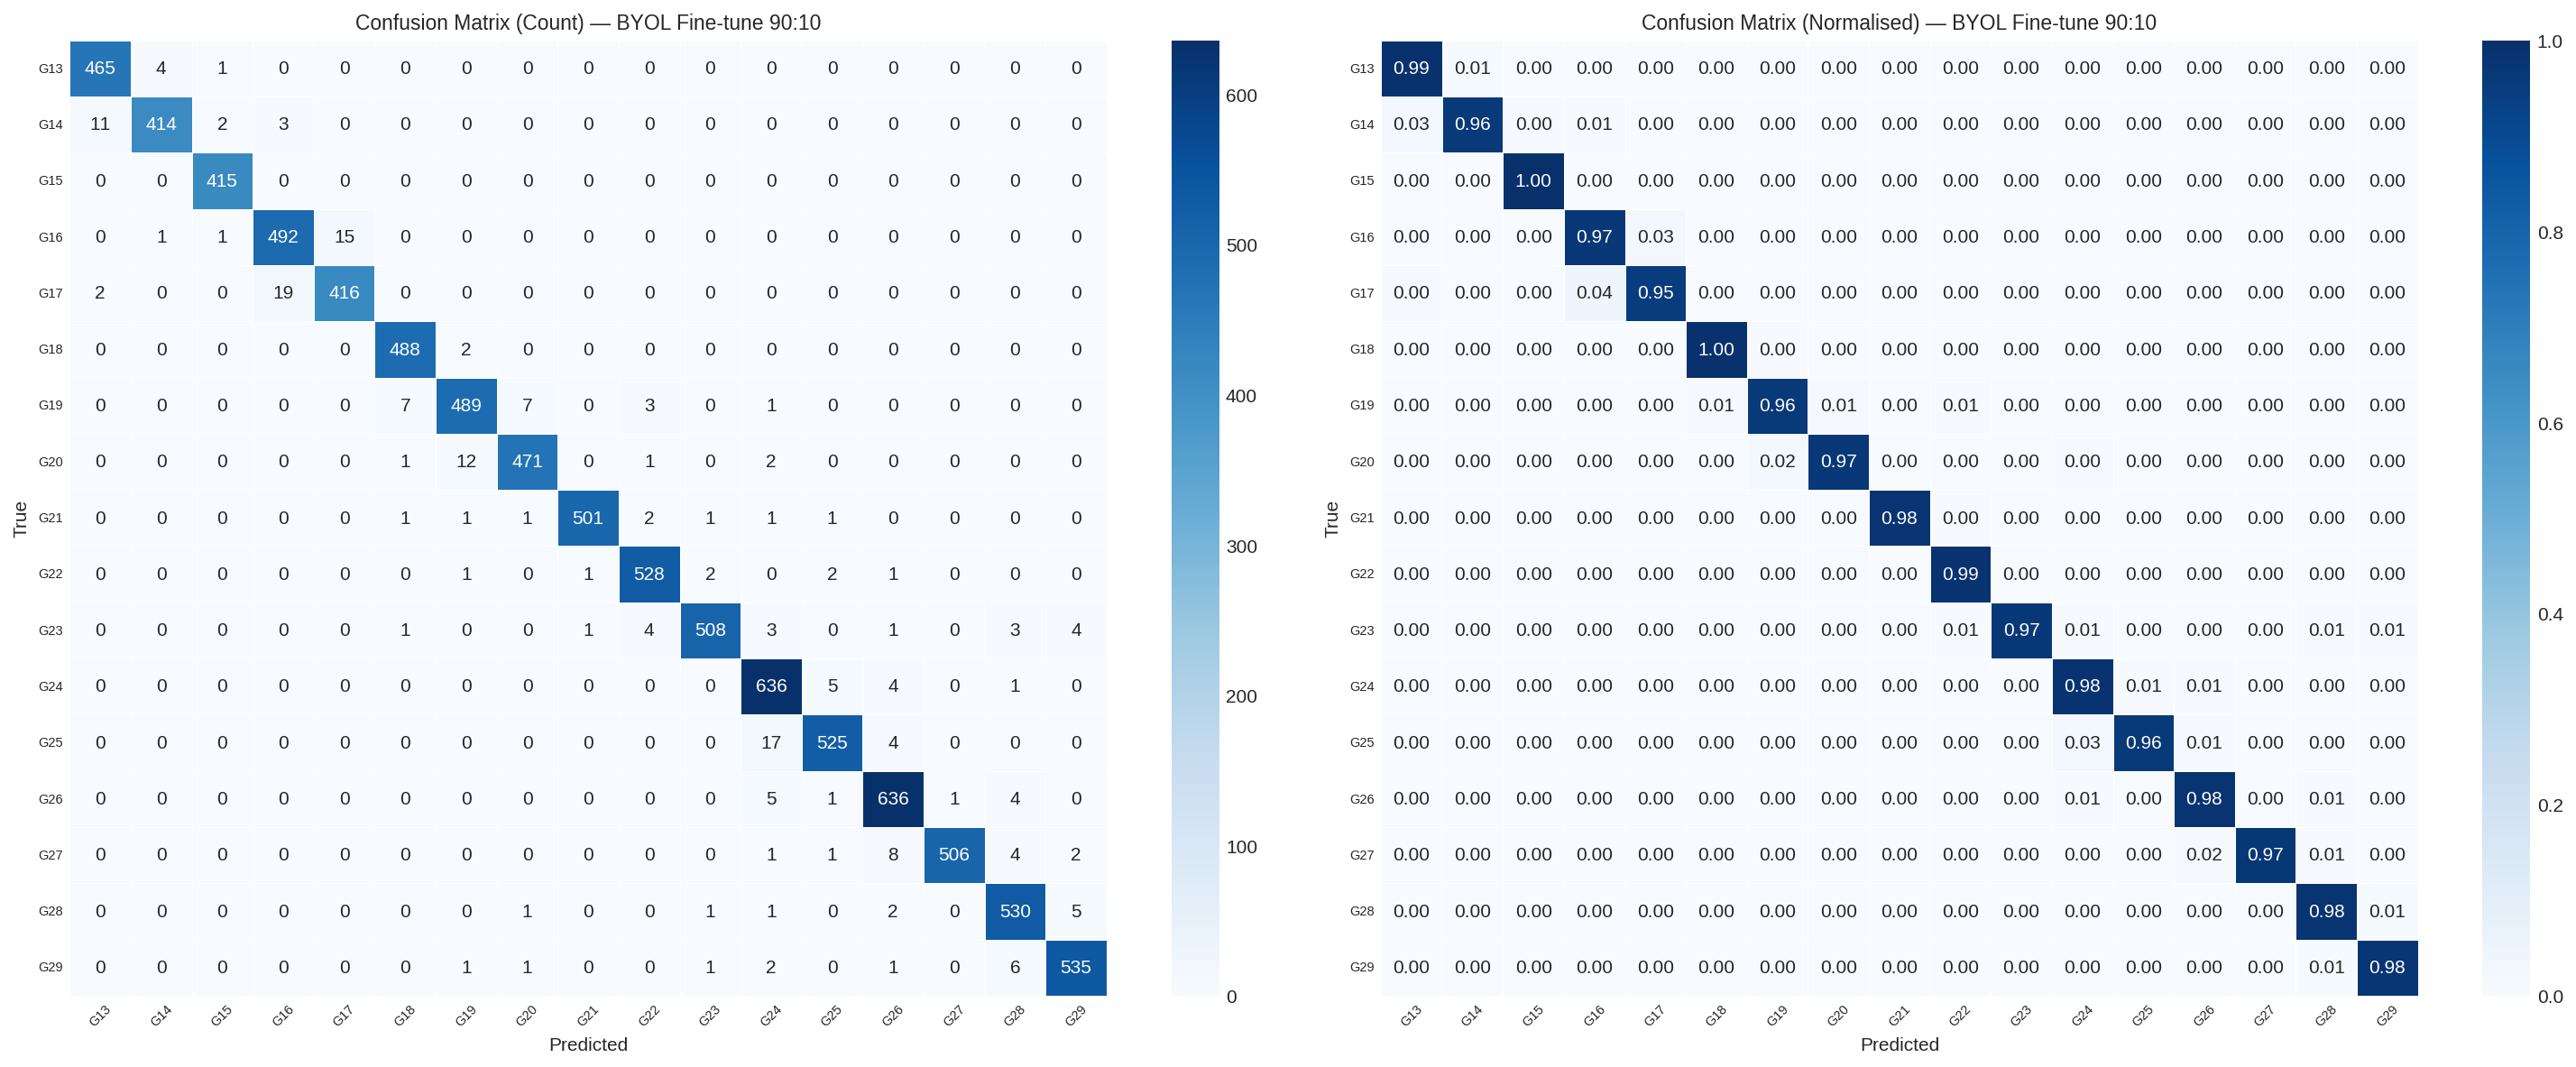


  CM BYOL MAIN


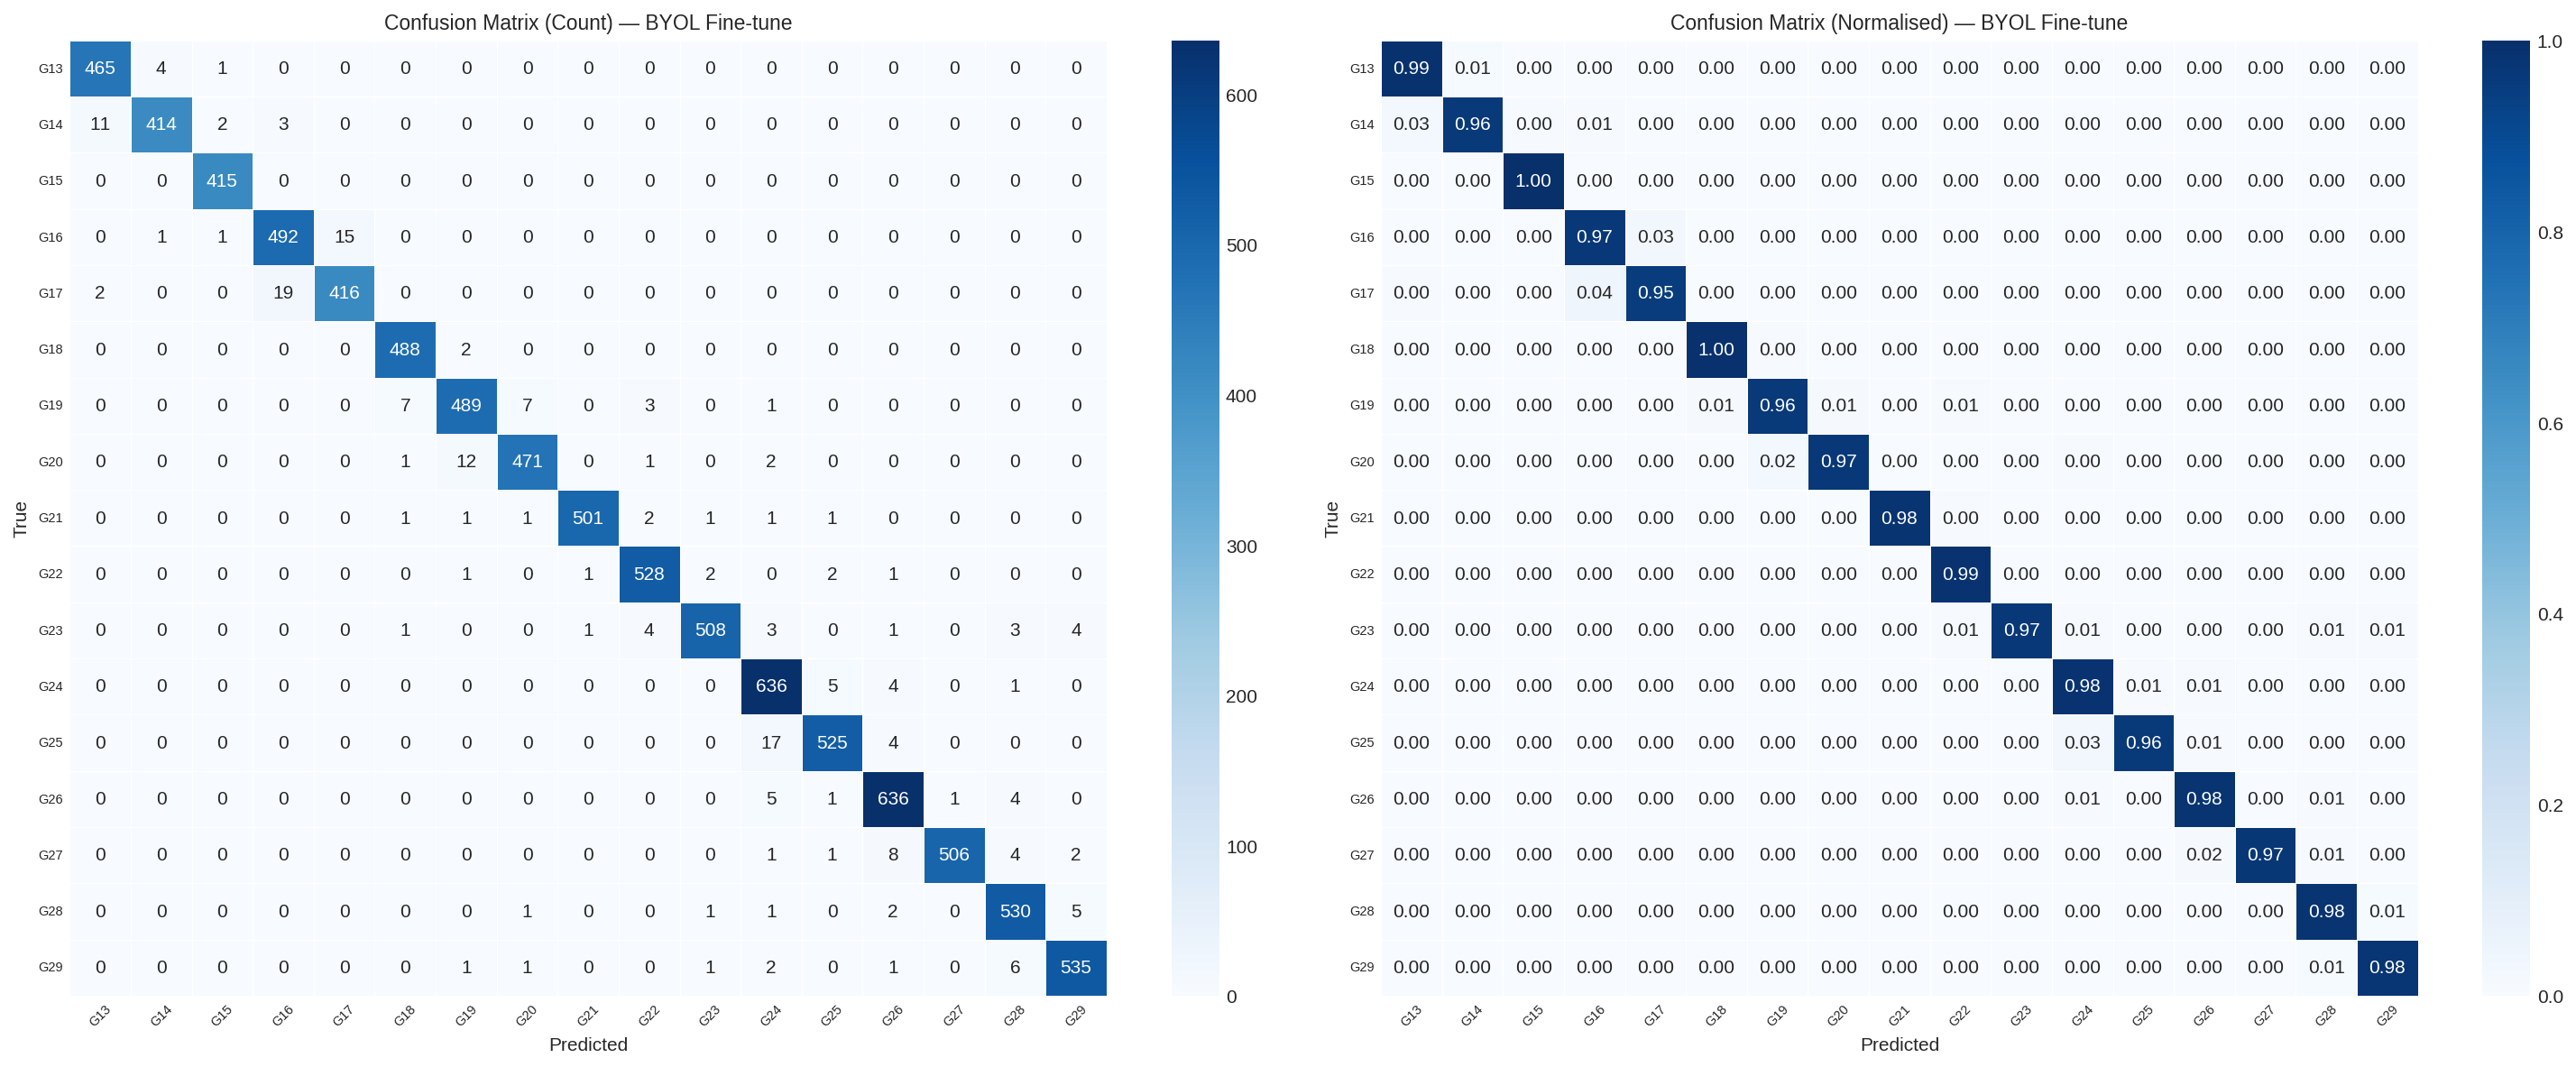


  LABEL EFFICIENCY


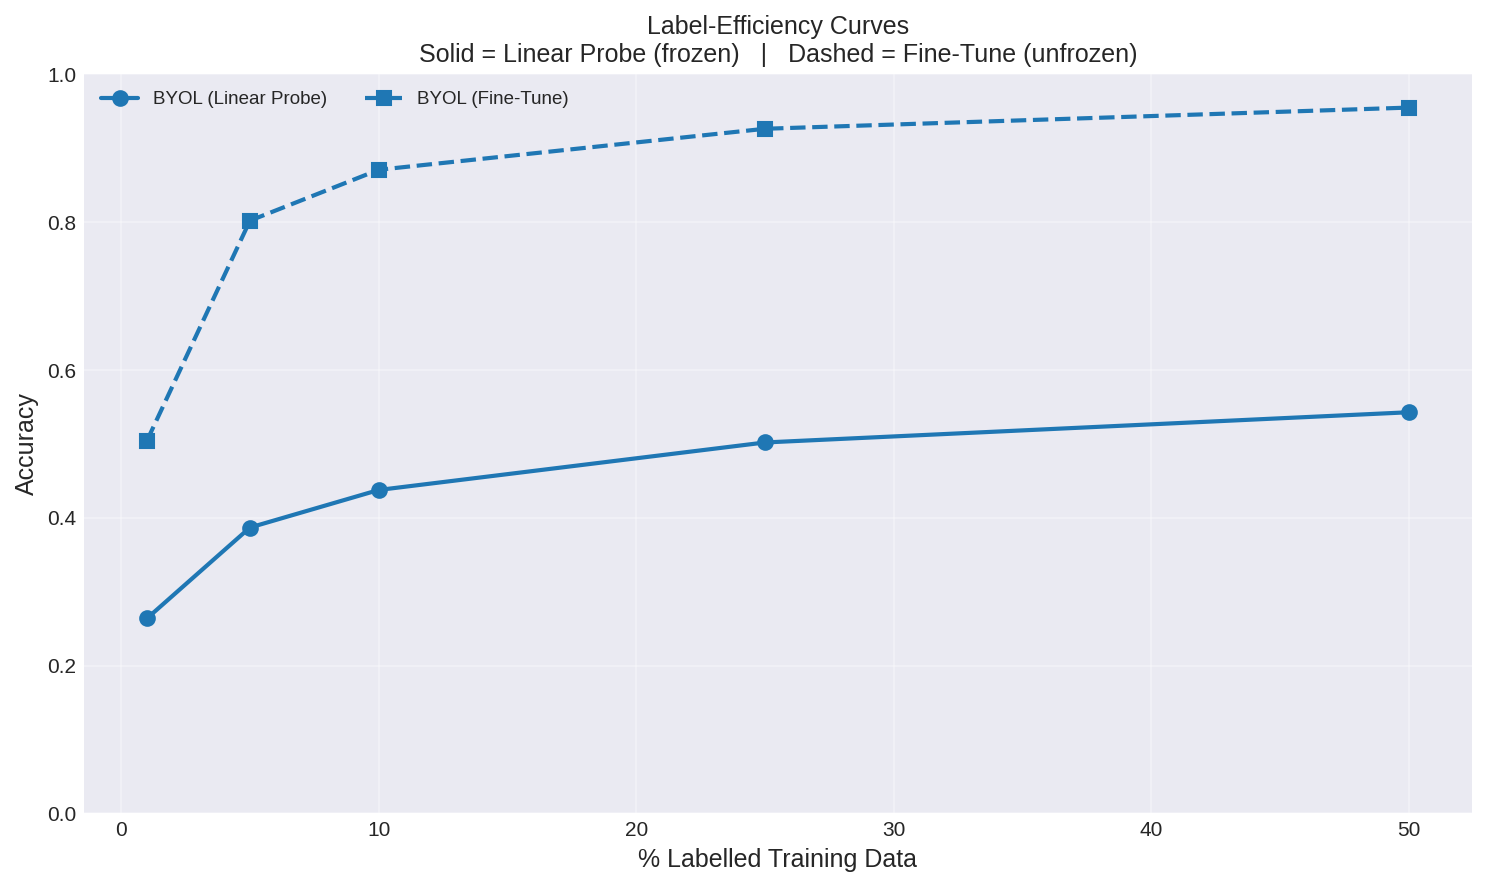


  PCA BYOL


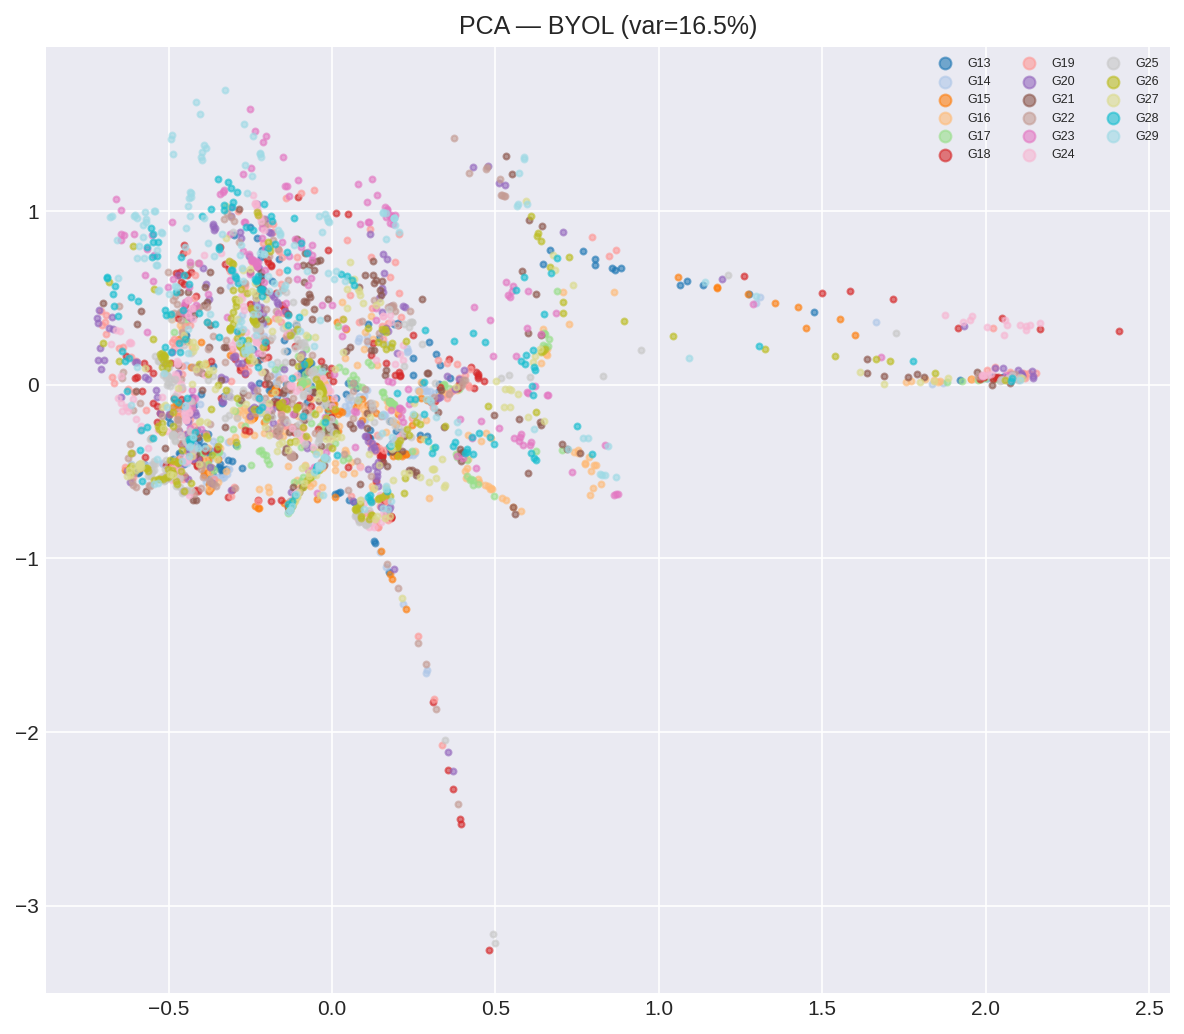


  ROC BYOL 90 10


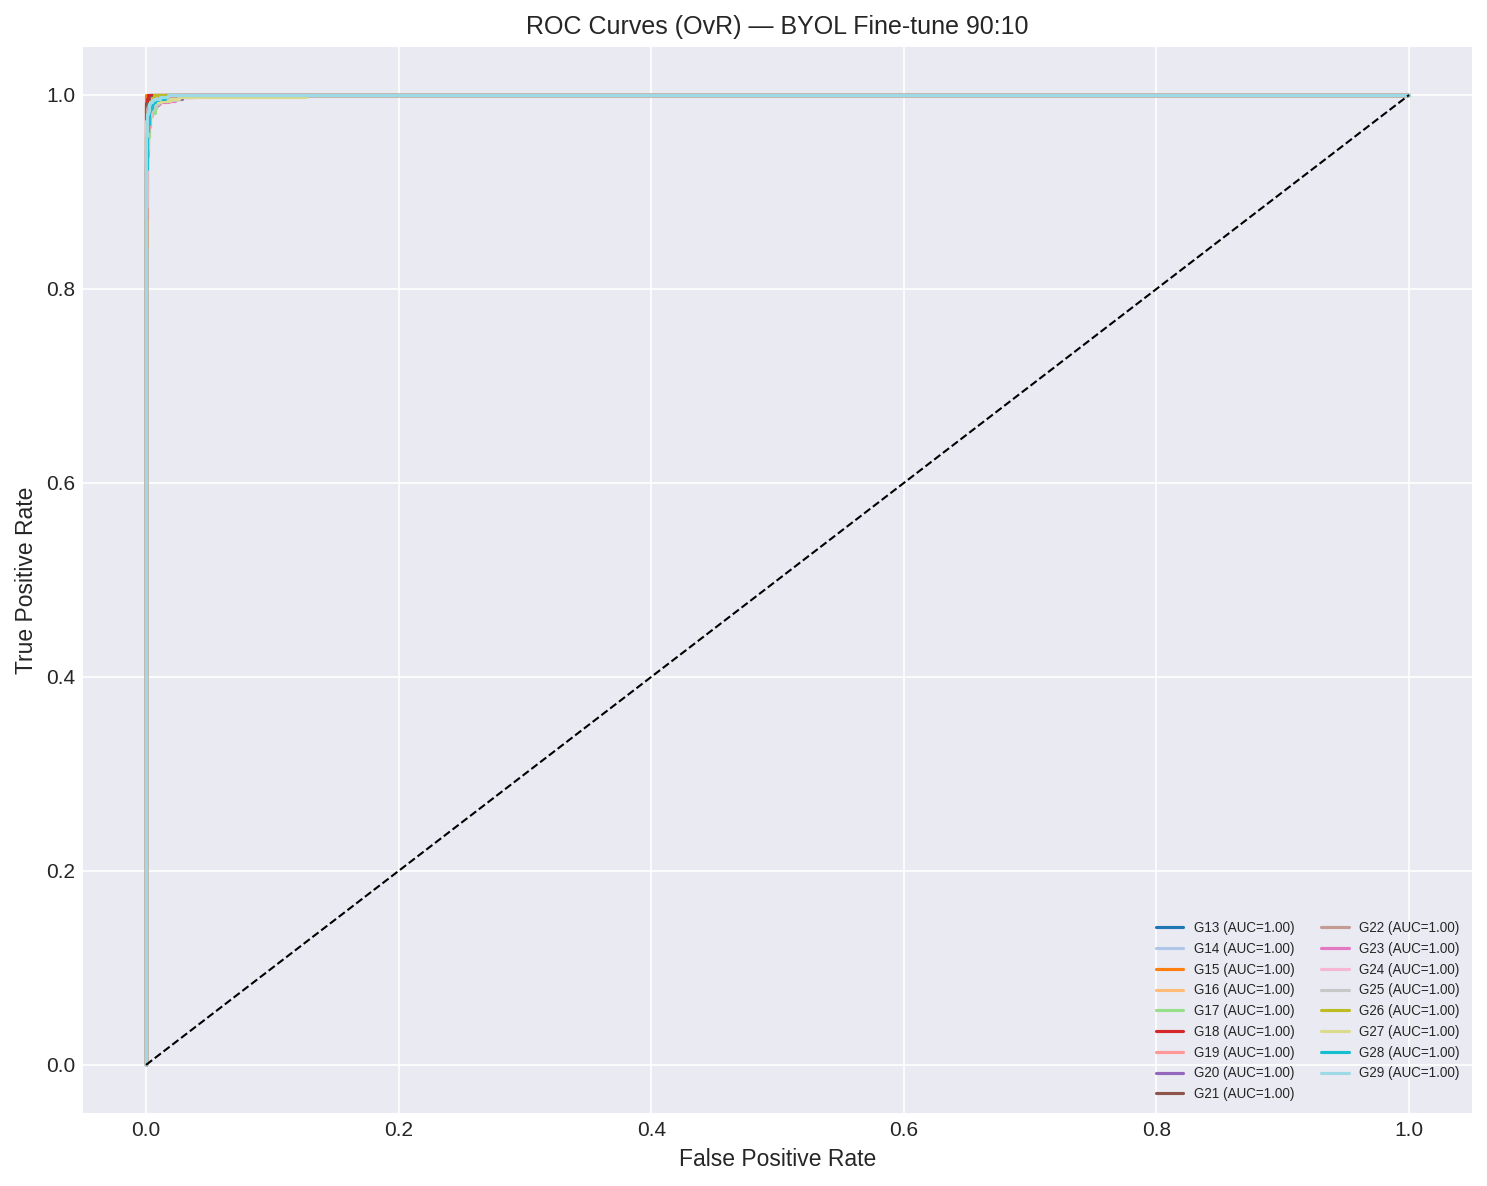


  ROC BYOL MAIN


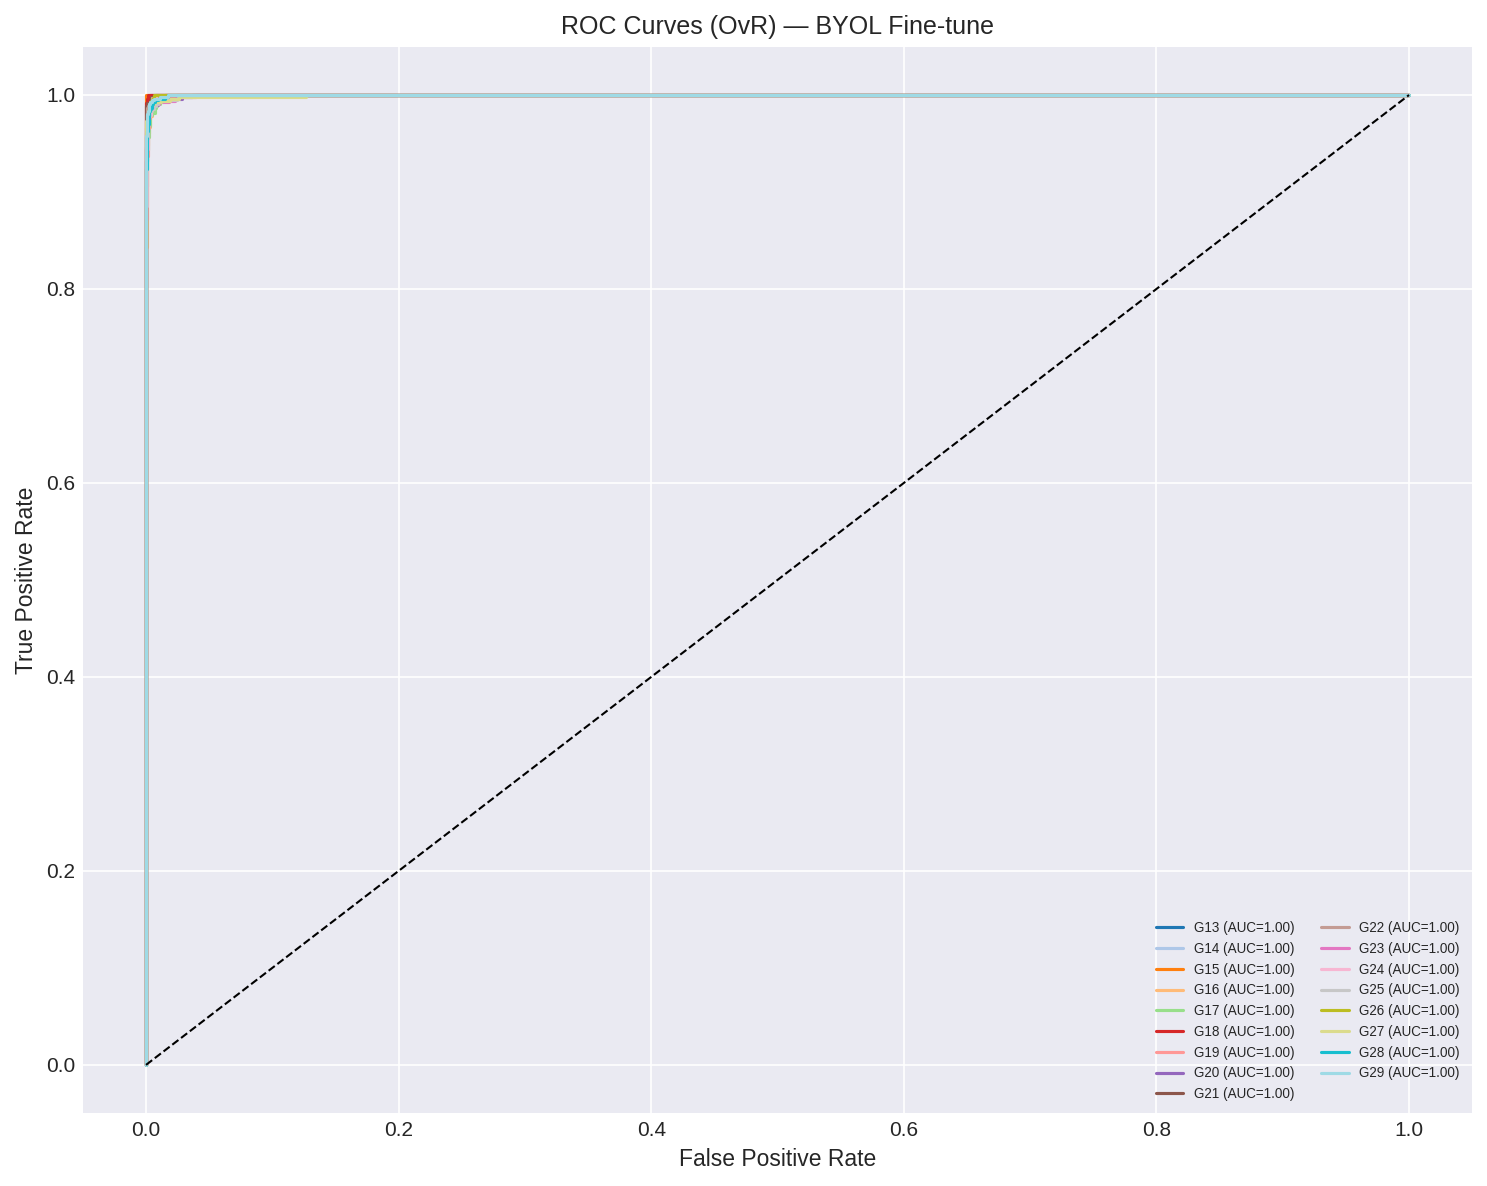


  SSL COMPARISON


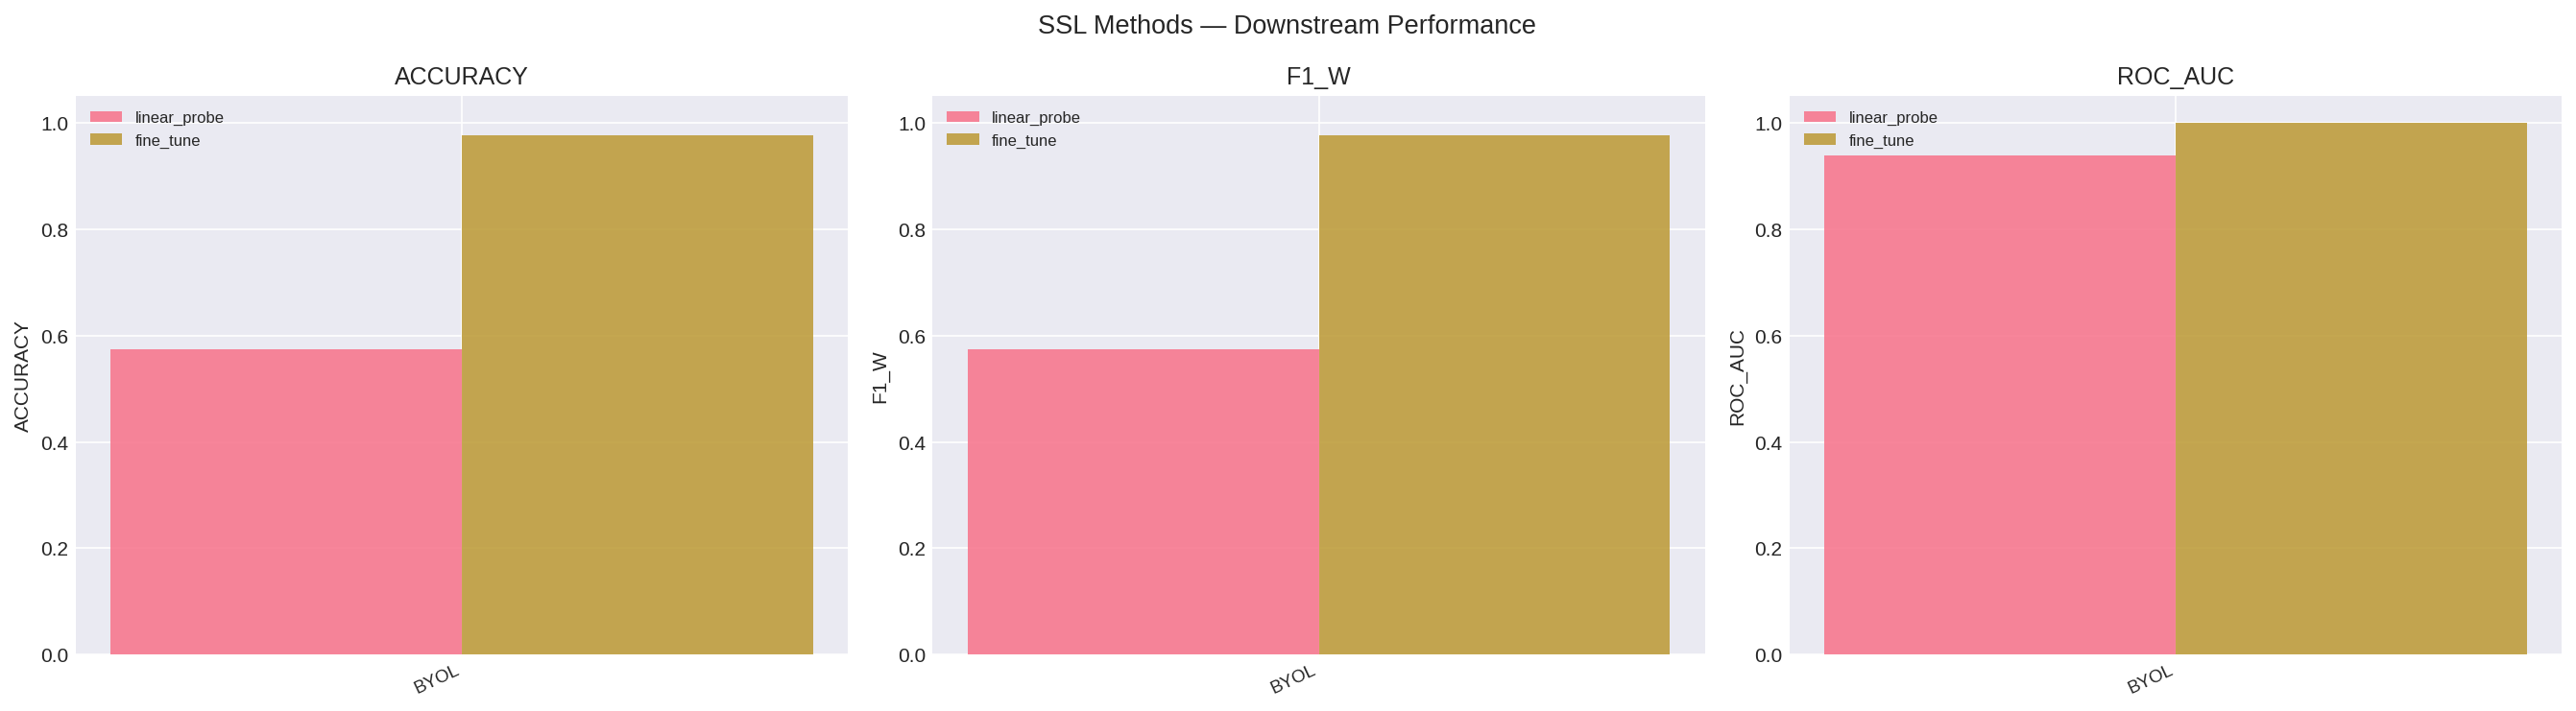


  SSL LOSS CURVES


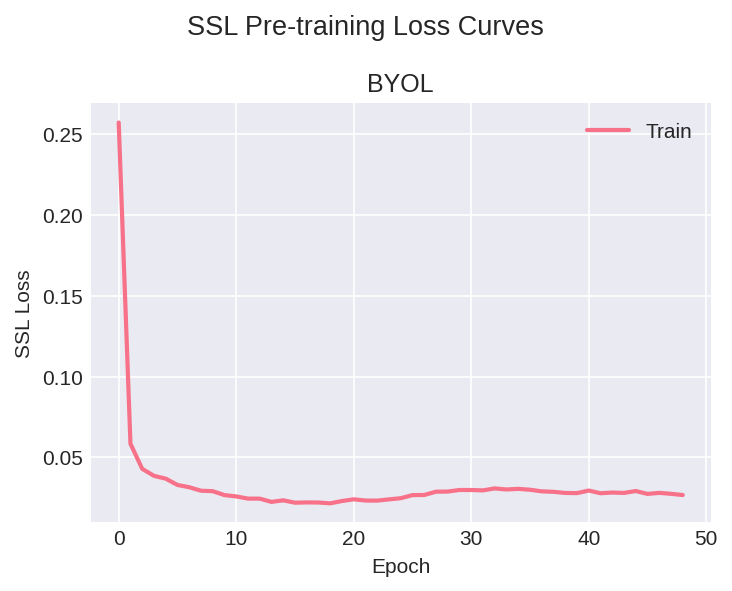


  TSNE BYOL


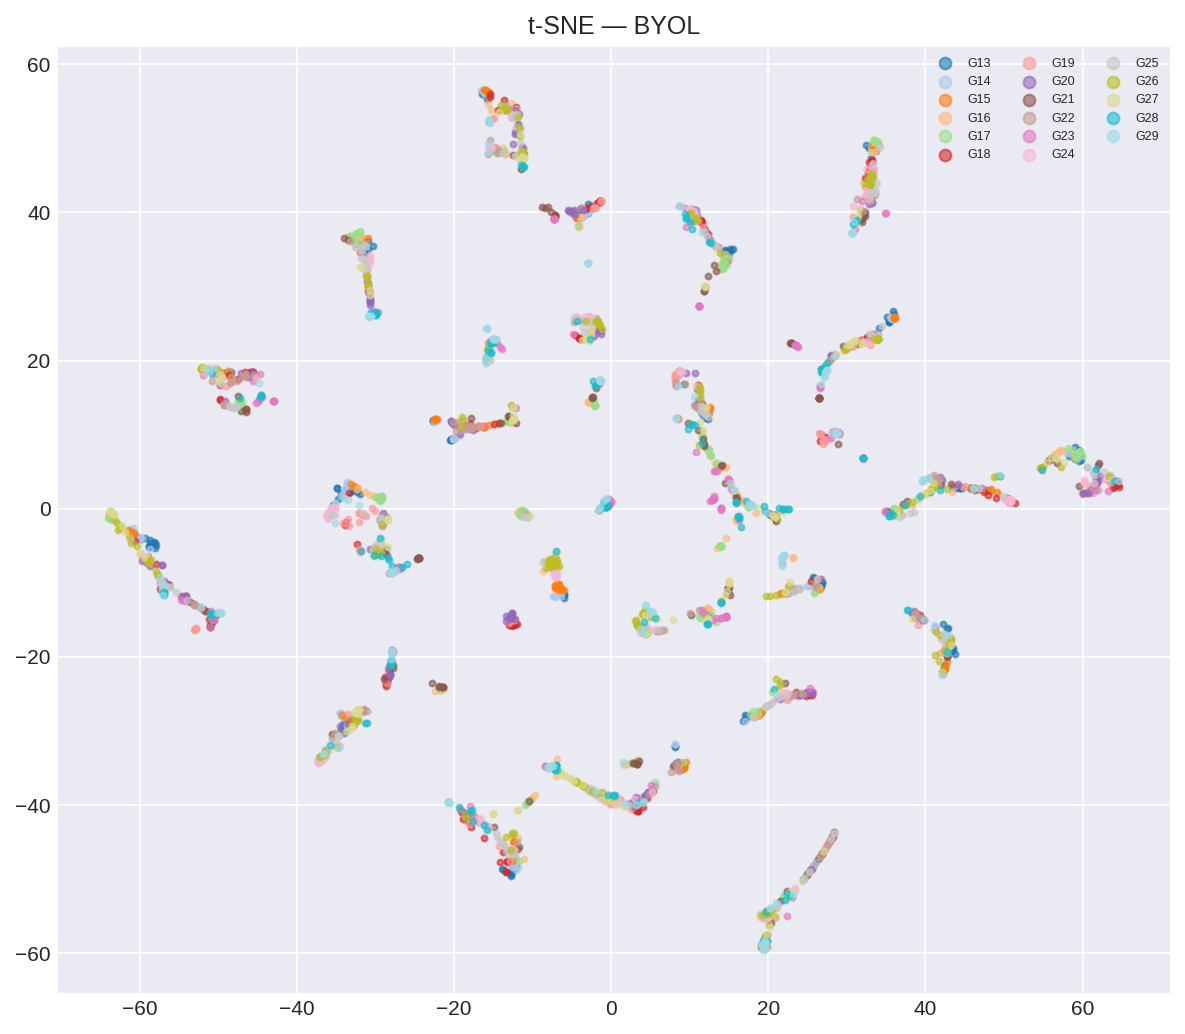


  UMAP BYOL


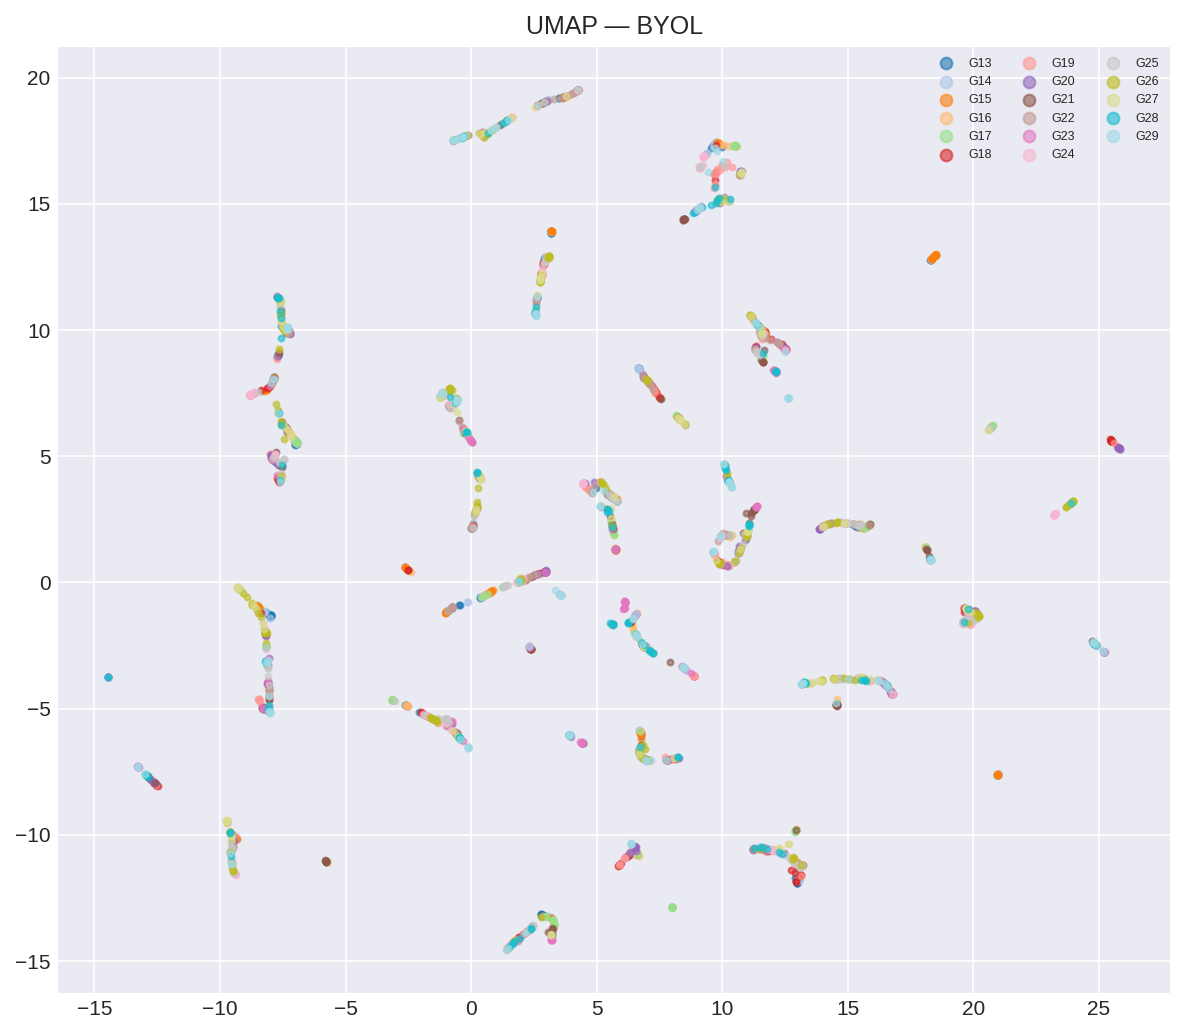

In [38]:
%matplotlib inline
from IPython.display import Image, display
from pathlib import Path

plot_dir = Path('/kaggle/working/plots_ssl')
all_pngs = sorted(plot_dir.glob('*.png'))

if not all_pngs:
    print("No plots found in", plot_dir)
else:
    print(f"Found {len(all_pngs)} plots\n")
    for fpath in all_pngs:
        print(f"\n{'='*60}")
        print(f"  {fpath.stem.upper().replace('_',' ')}")
        print(f"{'='*60}")
        display(Image(filename=str(fpath)))